 # **Projet de Fin d'Année (1ére année cycle ingénieur)**
 ** Prédiction des Défauts de Paiement par Carte de Crédit**

**1 : Introduction**

Bienvenue dans notre projet de fin de l'année ! On s'est penchée sur l'analyse et la prédiction des défauts de paiement par carte de crédit à Taïwan. Ce projet repose sur un ensemble de données complet qui nous offre un aperçu des comportements de paiement des clients.


**2 : Objectives**


Analyser les données pour identifier les facteurs significatifs ayant un impact sur les probabilités de défaut de paiement par carte de crédit pour les clients de la banque.

**4 : Compréhension du Système de Défaut de Paiement par Carte de Crédit**

Comment fonctionne un système de carte de crédit ?

Chaque mois, vous recevez une facture (X) reflétant vos dépenses par carte de crédit.
Vous effectuez un paiement (Y), généralement le montant minimum dû, avant la date d'échéance mentionnée sur le relevé de compte.
La facture du mois suivant inclut le solde restant du mois précédent (X - Y) ainsi que toutes nouvelles dépenses (X') effectuées pendant ce mois.
Vous effectuez un autre paiement (Y') pour couvrir une partie de la nouvelle facture.
Ce cycle se répète, chaque facture mensuelle incorporant les soldes précédents, les nouvelles dépenses et déduisant les paiements.
Manquer la date d'échéance du paiement minimum entraîne un retard de paiement, souvent accompagné de frais de retard. De plus, un retard continu peut conduire au défaut de paiement , on parle alors d'une personne défaillante.

# **Impotorter les packages**

In [1]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
import warnings
from scipy.stats import shapiro
pd.set_option('display.max_columns', None) 
plt.style.use('ggplot') 
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report , confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler




# Chargement des données


In [2]:
# Importing Data
data =pd.read_csv("..//input/default-of-credit-card-clients-dataset/UCI_Credit_Card.csv")

In [3]:
# Display the first 5 rows of the DataFrame .
data.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [4]:
# number of rows ans columns of dataframe
data.shape

(30000, 25)

# Qualité des données

In [5]:
# Get information about your dataset (type of each variable)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [6]:
# Get the summary statistics for columns
selected_columns = data[['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
                       'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']]

summary_statistics_selected = selected_columns.describe()
summary_statistics_selected

,LIMIT_BAL,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,167484.322667,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,129747.661567,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,10000.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,50000.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,140000.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,240000.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,1000000.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


In [7]:
#dataset duplicate value count

data.duplicated().value_counts()

False    30000
Name: count, dtype: int64


**Commentaire** : Il n y a pas de valeurs doubles

In [8]:
# checking missing values
data.isna().sum().sort_values()

ID                            0
PAY_AMT5                      0
PAY_AMT4                      0
PAY_AMT3                      0
PAY_AMT2                      0
PAY_AMT1                      0
BILL_AMT6                     0
BILL_AMT5                     0
BILL_AMT4                     0
BILL_AMT3                     0
BILL_AMT2                     0
PAY_AMT6                      0
BILL_AMT1                     0
PAY_5                         0
PAY_4                         0
PAY_3                         0
PAY_2                         0
PAY_0                         0
AGE                           0
MARRIAGE                      0
EDUCATION                     0
SEX                           0
LIMIT_BAL                     0
PAY_6                         0
default.payment.next.month    0
dtype: int64

> **commentaire**: Il n y a pas de valeurs manquantes

# Visualisation des données : Comprendre la relation entre les variables.
# 1- Analyse univariée des variables qualitatives

* **Visualisation de la variable cible : default.payment.next.month**

In [9]:
#checking target values
data['default.payment.next.month'].value_counts()

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

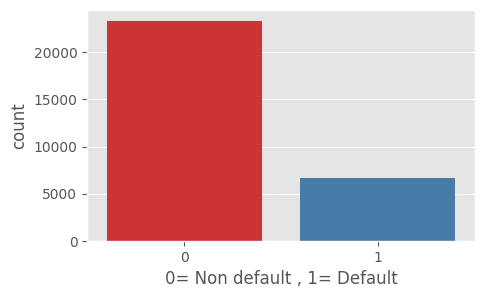

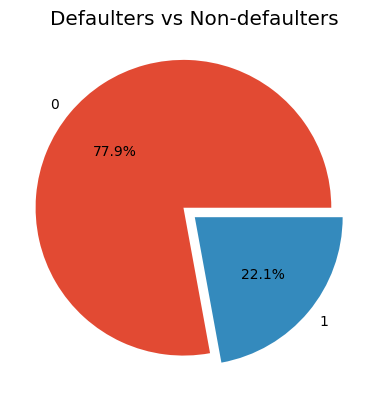

In [10]:
plt.figure(figsize=(5,3))
sns.countplot(x='default.payment.next.month',data=data , palette='Set1')
plt.xlabel("0= Non default , 1= Default")
plt.show()
# Plotting pie chart
data['default.payment.next.month'].value_counts().plot(kind='pie', explode=[0.1, 0], autopct="%1.1f%%")
plt.title('Defaulters vs Non-defaulters')
plt.ylabel('')
plt.show()

> On peut voir que notre dataset se compose de 77% de clients qui ne sont pas censés faire défaut de paiement, tandis que 23% des clients sont censés faire défaut de paiement
> 
> Il y a un déséquilibre dans la distribution des classes.







* **Visualisation des variables : Education ,Marriage et Sexe**

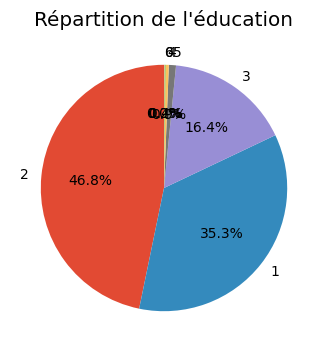

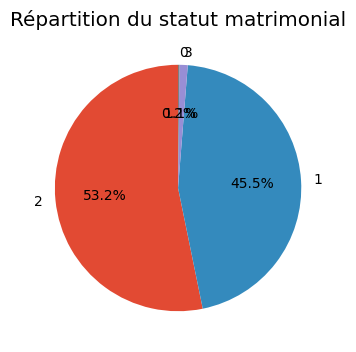

In [11]:
# Tracer le diagramme pour la variable "education"
plt.figure(figsize=(5, 4))
data['EDUCATION'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Répartition de l'éducation")
plt.ylabel("")  
plt.show()

# Tracer le diagramme circulaire pour la variable "marriage"
plt.figure(figsize=(5, 4))
data['MARRIAGE'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Répartition du statut matrimonial")
plt.ylabel("")  
plt.show()

In [12]:
education_counts = data['EDUCATION'].value_counts()
print(education_counts)
marriage_counts = data['MARRIAGE'].value_counts()
print(marriage_counts)




EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64
MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64


In [13]:
# Remplacer les valeurs 4, 5 , 0 et 6 par la valeur 4 (others) : EDUCATION
data['EDUCATION'].replace([4, 5, 6, 0], 4, inplace=True)
print(data['EDUCATION'].unique())

# Remplacer les valeurs 0 et 3 par la valeur 0  (others) : MARRIAGE
data['MARRIAGE'].replace([3, 0], 0, inplace=True)
print(data['MARRIAGE'].unique())

[2 1 3 4]
[1 2 0]


In [14]:
sex_counts = data['SEX'].value_counts()
sex_counts

SEX
2    18112
1    11888
Name: count, dtype: int64

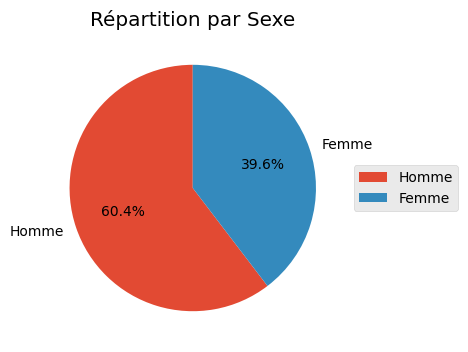

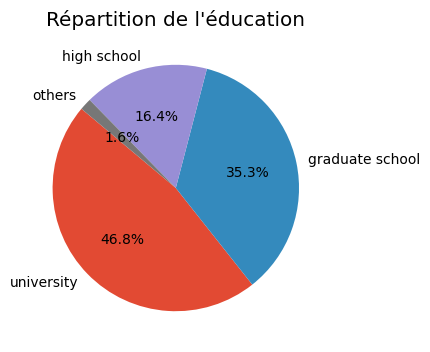

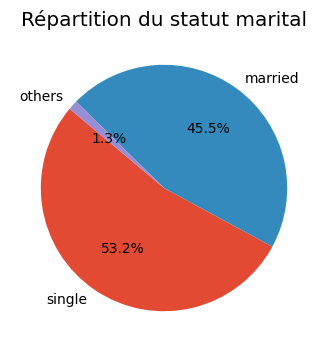

In [15]:
# Sexe
sex_counts = data['SEX'].value_counts()
sex_labels = ['Homme', 'Femme']
plt.figure(figsize=(4, 4))
plt.pie(sex_counts, labels=sex_labels, autopct='%1.1f%%', startangle=90)
plt.title('Répartition par Sexe')
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

#EDUACTION
education_labels = {1: 'graduate school', 2: 'university', 3: 'high school', 4: 'others'}
plt.figure(figsize=(4, 4))
education_counts = data['EDUCATION'].value_counts()
plt.pie(education_counts, labels=[education_labels[x] for x in education_counts.index], autopct='%1.1f%%', startangle=140)
plt.title('Répartition de l\'éducation')
plt.show()

#MARRIAGE 
marriage_labels = {1: 'married', 2: 'single', 0: 'others'}
plt.figure(figsize=(4, 4))
marriage_counts = data['MARRIAGE'].value_counts()
plt.pie(marriage_counts, labels=[marriage_labels[x] for x in marriage_counts.index], autopct='%1.1f%%', startangle=140)
plt.title('Répartition du statut marital')
plt.show()

>Notre dataset se compose de 60.4% de clientes femmes et 39.6% de clients hommes.
Il y a 53.2% de clients célibataires (2), 45.5% qui sont mariés (1), 1.3% sont classés comme "autres" (3) (divorcés ou séparés) .
46.8% des clients ont un niveau universitaire (2), 35.3% sont diplômés d'études supérieures, 16.4% ont suivi l'enseignement secondaire (3) et 1.6% sont classés comme "autres".

* **État de paiement (PAY_X)**

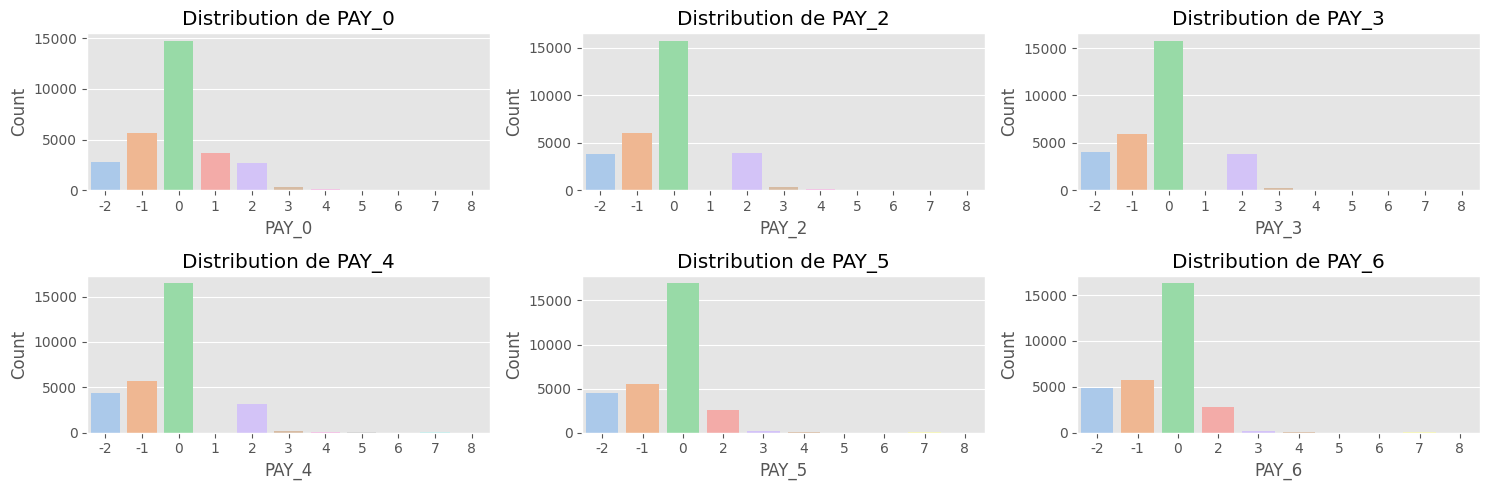

Décompte des modalités avant les remplacements pour 'PAY_0':
PAY_0
 0    14737
-1     5686
 1     3688
-2     2759
 2     2667
 3      322
 4       76
 5       26
 8       19
 6       11
 7        9
Name: count, dtype: int64
Décompte des modalités avant les remplacements pour 'PAY_2':
PAY_2
 0    15730
-1     6050
 2     3927
-2     3782
 3      326
 4       99
 1       28
 5       25
 7       20
 6       12
 8        1
Name: count, dtype: int64
Décompte des modalités avant les remplacements pour 'PAY_3':
PAY_3
 0    15764
-1     5938
-2     4085
 2     3819
 3      240
 4       76
 7       27
 6       23
 5       21
 1        4
 8        3
Name: count, dtype: int64
Décompte des modalités avant les remplacements pour 'PAY_4':
PAY_4
 0    16455
-1     5687
-2     4348
 2     3159
 3      180
 4       69
 7       58
 5       35
 6        5
 1        2
 8        2
Name: count, dtype: int64
Décompte des modalités avant les remplacements pour 'PAY_5':
PAY_5
 0    16947
-1     5539
-2     45

In [16]:
pay_columns = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
plt.figure(figsize=(15, 5))
for i, col in enumerate(pay_columns, 1):
    plt.subplot(2, 3, i)
    sns.countplot(x=col, data=data, palette='pastel')
    plt.title(f'Distribution de {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

for col in pay_columns:
    print(f"Décompte des modalités avant les remplacements pour '{col}':")
    print(data[col].value_counts())


Décompte des modalités après les remplacements pour 'PAY_0':
PAY_0
0    23182
1     3688
2     2667
3      463
Name: count, dtype: int64
Décompte des modalités après les remplacements pour 'PAY_2':
PAY_2
0    25562
2     3927
3      483
1       28
Name: count, dtype: int64
Décompte des modalités après les remplacements pour 'PAY_3':
PAY_3
0    25787
2     3819
3      390
1        4
Name: count, dtype: int64
Décompte des modalités après les remplacements pour 'PAY_4':
PAY_4
0    26490
2     3159
3      349
1        2
Name: count, dtype: int64
Décompte des modalités après les remplacements pour 'PAY_5':
PAY_5
0    27032
2     2626
3      342
Name: count, dtype: int64
Décompte des modalités après les remplacements pour 'PAY_6':
PAY_6
0    26921
2     2766
3      313
Name: count, dtype: int64


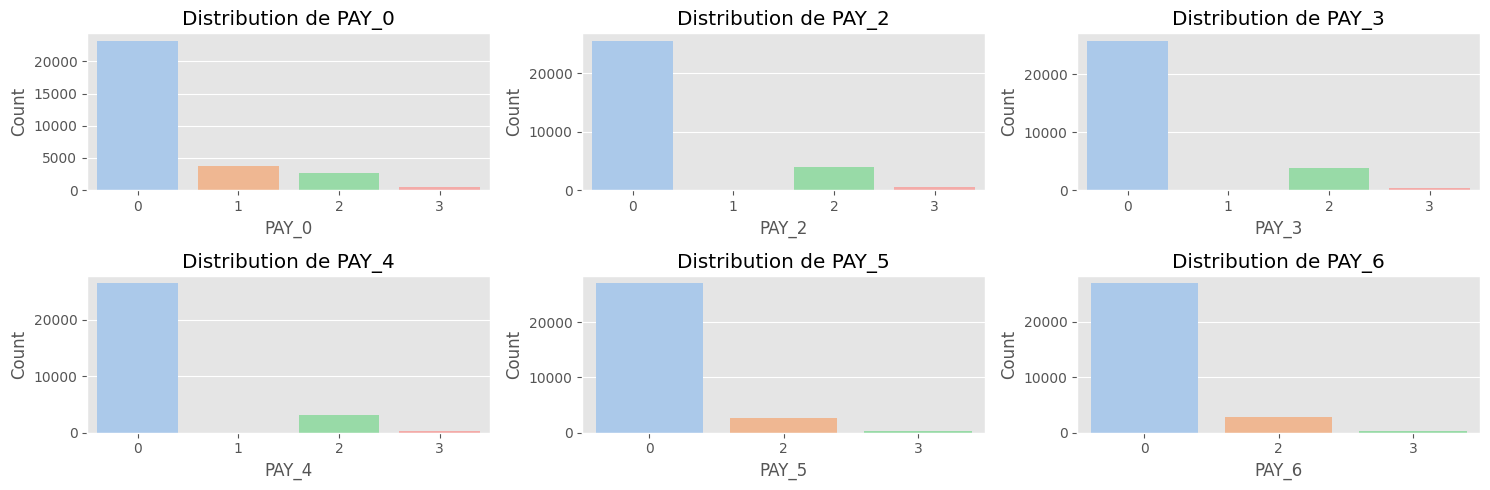

In [17]:
pay_columns = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
for col in pay_columns:
    data[col].replace([-2, -1, 0], 0, inplace=True)
    data[col].replace([3, 4, 5 ,6,7,8], 3, inplace=True)

for col in pay_columns:
    print(f"Décompte des modalités après les remplacements pour '{col}':")
    print(data[col].value_counts())

plt.figure(figsize=(15, 5))
for i, col in enumerate(pay_columns, 1):
    plt.subplot(2, 3, i)
    sns.countplot(x=col, data=data, palette='pastel')
    plt.title(f'Distribution de {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

> la majorité des clients effectuent leurs paiements en avance ou à temps.
Pour les clients qui ont un retard de paiement, la plupart ont un retard de deux mois.

# 2- Analyse univariée des variables quantitatives

* **Visualisation de LIMIT_BAL** 

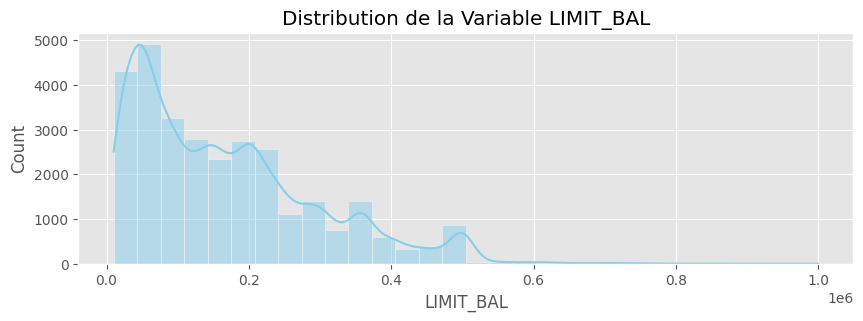

In [18]:
# Distribution de la variable LIMIT_BAL
plt.figure(figsize=(10, 3))
sns.histplot(data['LIMIT_BAL'], bins=30, kde=True, color='skyblue')
plt.title('Distribution de la Variable LIMIT_BAL')
plt.xlabel('LIMIT_BAL')
plt.ylabel('Count')
plt.show()

**Test de normalité pour LIMIT_BAL**

In [19]:
sample_size = 1000  

# Extraire un échantillon de la variable 'LIMIT_BAL'
limit_bal_sample = data['LIMIT_BAL'].sample(n=sample_size, random_state=42) 
stat, p_value = shapiro(limit_bal_sample)

# Afficher les résultats
print(f"Statistique du test de Shapiro-Wilk : {stat}")
print(f"P-valeur : {p_value}")

alpha = 0.05
if p_value > alpha:
    print(f"L'échantillon de 'LIMIT_BAL' suit une distribution normale (p > {alpha})")
else:
    print(f"L'échantillon de 'LIMIT_BAL' ne suit pas une distribution normale (p <= {alpha})")

Statistique du test de Shapiro-Wilk : 0.9056479334831238
P-valeur : 2.2781886818655317e-24
L'échantillon de 'LIMIT_BAL' ne suit pas une distribution normale (p <= 0.05)


> La distribution de la variable LIMIT_BAL est asymétrique et inclinée vers la gauche. La majorité des clients possèdent un montant de crédit inférieur à 250 000 dollars NT

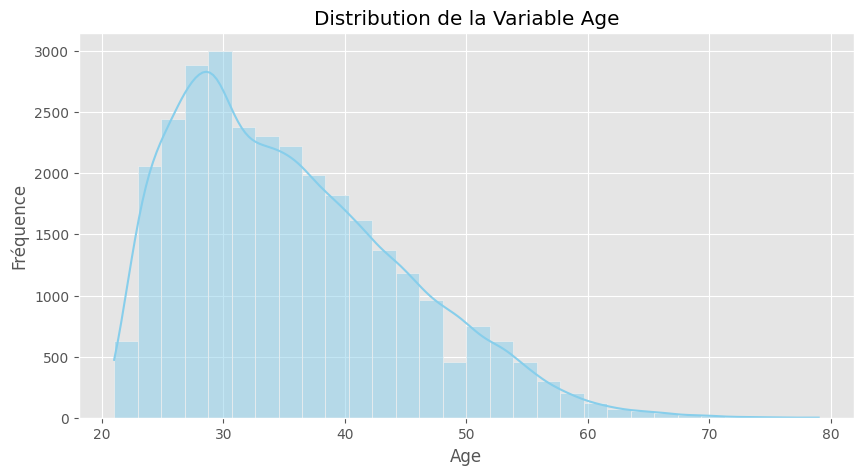

In [20]:
# Distribution de la variable AGE
plt.figure(figsize=(10, 5))
sns.histplot(data['AGE'], bins=30, kde=True, color='skyblue')
plt.title('Distribution de la Variable Age')
plt.xlabel('Age')
plt.ylabel('Fréquence')
plt.show()

In [21]:
# Créer un échantillon aléatoire de taille 5000 à partir de la variable "AGE"
my_sample = np.random.choice(data['AGE'], size=5000, replace=True)

statistic, p_value = shapiro(my_sample)

alpha = 0.05
print(f"Statistique de test : {statistic}")
print(f"P-valeur : {p_value}")
print("Normalité : Oui" if p_value > alpha else "Normalité : Non")

Statistique de test : 0.9510712027549744
P-valeur : 6.078773883705555e-38
Normalité : Non


> La distribution de la variable ÂGE est asymétrique et inclinée vers la gauche, avec la majorité des clients étant jeunes (âgés entre 22 et 40 ans).

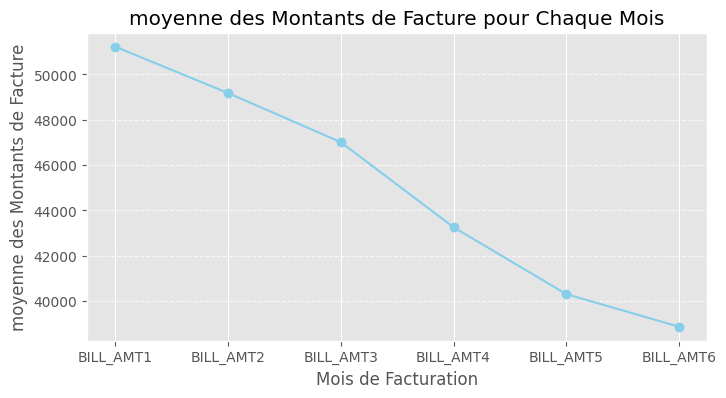

In [22]:
# Calculer la moyenne de chaque variable de montant de facture
sum_bill_amt = data[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']].mean()

# Plot line chart avec des points liés par une ligne
plt.figure(figsize=(8, 4))
plt.plot(sum_bill_amt.index, sum_bill_amt.values, marker='o', linestyle='-', color='skyblue')
plt.title('moyenne des Montants de Facture pour Chaque Mois')
plt.xlabel('Mois de Facturation')
plt.ylabel('moyenne des Montants de Facture')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

> Le montant de facture augmente d’un mois à un autre ce qui signifie que les clients ne remboursent pas la totalité de leur crédit ou bien ils ne le remboursent même pas.

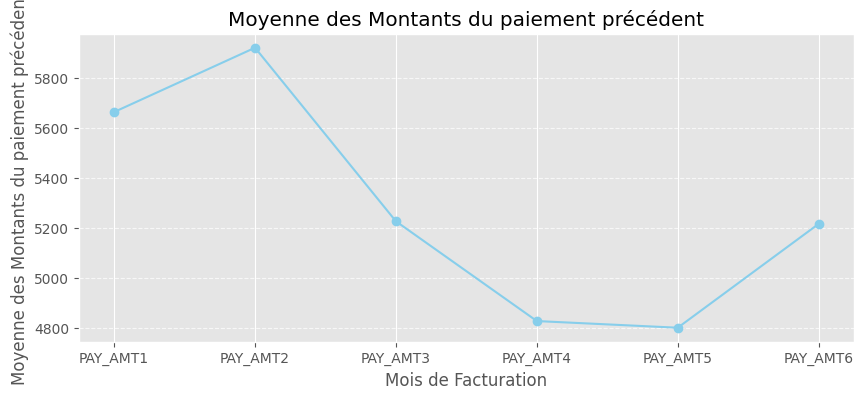

In [23]:
# Calculer la moyenne de chaque variable de Montant du paiement précédent
sum_PAY_AMT = data[['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].mean()

# Plot line chart avec des points liés par une ligne
plt.figure(figsize=(10, 4))
plt.plot(sum_PAY_AMT.index, sum_PAY_AMT.values, marker='o', linestyle='-', color='skyblue')
plt.title('Moyenne des Montants du paiement précédent')
plt.xlabel('Mois de Facturation')
plt.ylabel('Moyenne des Montants du paiement précédent')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

> La moyenne des montants du paiement précèdent n’est pas stable au fil des mois , elle varie d’un mois à un autre.

# 3- Analyse bivariée 

#  SEX vs target

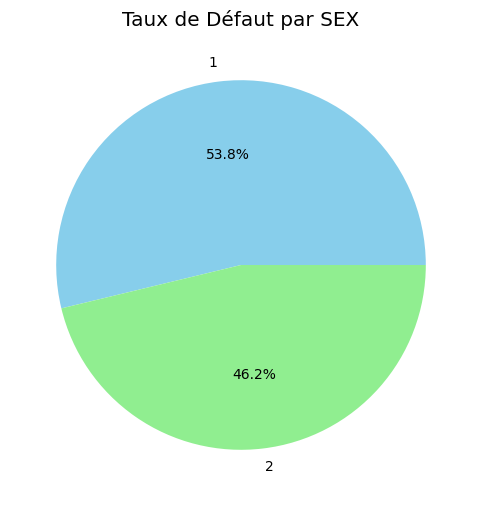

In [24]:
# Analyse bivariée entre SEX et Target
default_rate_by_sex = data.groupby('SEX')['default.payment.next.month'].mean()

# Affichage des taux de défaut par SEX
plt.figure(figsize=(6, 6))
plt.pie(default_rate_by_sex, labels=default_rate_by_sex.index, autopct='%1.1f%%', colors=['skyblue', 'lightgreen'])
plt.title('Taux de Défaut par SEX')
plt.show()

> Taux de défaut de paiement pour les clients masculins (SEX=1) : environ 53.8%
> 
> Taux de défaut de paiement pour les clientes féminines (SEX=2) : environ 46.2%
> 
> La différence entre ces taux suggère une légère tendance à un taux de défaut plus élevé chez les clients masculins.

#  Test du chi-carré (chi2)
* H0 (hypothèse nulle): les deux variables sont indépendantes.
* H1 (hypothèse alternative): les deux variables sont dépendantes.

In [25]:
#Créer une table de contingence entre SEX et la variable cible
contingency_table = pd.crosstab(data['SEX'], data['default.payment.next.month'])
contingency_table
# Appliquer le test du chi2
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

# Afficher les résultats
print(f"Statistique du test du chi2 : {chi2_stat}")
print(f"P-valeur : {p_value}")
print(f"degrés de liberté : {dof}")
print("Tableau des fréquences attendues :")
print(expected)

Statistique du test du chi2 : 47.70879689062111
P-valeur : 4.944678999412044e-12
degrés de liberté : 1
Tableau des fréquences attendues :
[[ 9258.3744  2629.6256]
 [14105.6256  4006.3744]]


> -> La variable SEX affecte la variable cible , ces deux variables sont dépendantes.
 

# Niveau d'Éducation vs Traget

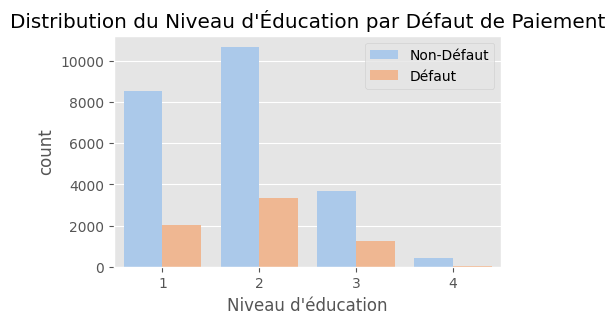

In [26]:
#analyse bivarié : niveau d'Éducation vs Traget_column
plt.figure(figsize=(5, 3))
sns.countplot(x='EDUCATION', hue='default.payment.next.month', data=data, palette='pastel')
plt.xlabel('Niveau d\'éducation')
plt.ylabel('count')
plt.title('Distribution du Niveau d\'Éducation par Défaut de Paiement')
plt.legend(['Non-Défaut', 'Défaut'], loc='upper right')
plt.show()

EDUCATION
1    0.192348
2    0.237349
3    0.251576
4    0.070513
Name: default.payment.next.month, dtype: float64


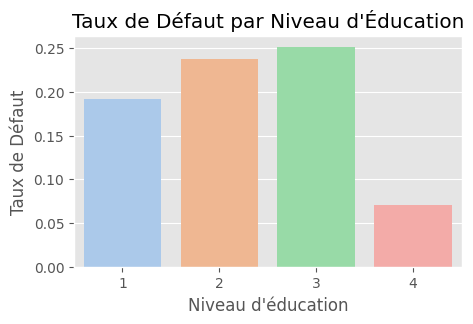

In [27]:
# Calculer le taux de défaut par niveau d'éducation
default_rate_by_education = data.groupby('EDUCATION')['default.payment.next.month'].mean()
print(default_rate_by_education)
plt.figure(figsize=(5, 3))
sns.barplot(x=default_rate_by_education.index, y=default_rate_by_education.values, palette='pastel')
plt.xlabel('Niveau d\'éducation')
plt.ylabel('Taux de Défaut')
plt.title('Taux de Défaut par Niveau d\'Éducation')
plt.show()

> les clients ayant des niveaux d'éducation plus avancés ont tendance à avoir des taux de défaut de paiement moins élevés, tandis que les clients ayant des niveaux d'éducation moins avancés ou inconnus ont tendance à avoir des taux de défaut de paiement plus élevés.

#  Test du chi-carré (chi2)
* H0 (hypothèse nulle):  les deux variables sont indépendantes..
* H1 (hypothèse alternative):  les deux variables sont dépendantes.


In [28]:
#Créer une table de contingence entre niveau d'éducation et la variable cible
contingency_table = pd.crosstab(data['EDUCATION'], data['default.payment.next.month'])
contingency_table
# Appliquer le test du chi2
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

# Afficher les résultats
print(f"Statistique du test du chi2 : {chi2_stat}")
print(f"P-valeur : {p_value}")
print(f"degrés de liberté : {dof}")
print("Tableau des fréquences attendues :")
print(expected)

Statistique du test du chi2 : 160.40995107224546
P-valeur : 1.4950645648106153e-34
degrés de liberté : 3
Tableau des fréquences attendues :
[[ 8243.598   2341.402 ]
 [10926.564   3103.436 ]
 [ 3829.3596  1087.6404]
 [  364.4784   103.5216]]


> -> La variable EDUCATION  affecte la variable cible , ces deux variables sont dépendantes.
> 

# MARRIAGE VS Target 

MARRIAGE
0    0.236074
1    0.234717
2    0.209283
Name: default.payment.next.month, dtype: float64


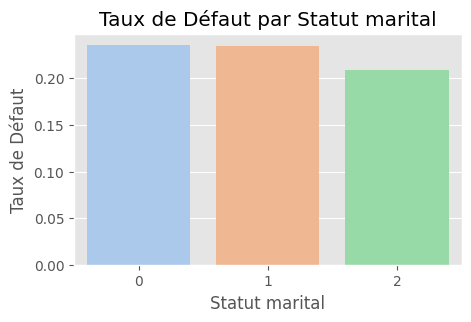

In [29]:
# Calculer le taux de défaut par statut marital
default_rate_by_education = data.groupby('MARRIAGE')['default.payment.next.month'].mean()
print(default_rate_by_education)
plt.figure(figsize=(5, 3))
sns.barplot(x=default_rate_by_education.index, y=default_rate_by_education.values, palette='pastel')
plt.xlabel('Statut marital')
plt.ylabel('Taux de Défaut')
plt.title('Taux de Défaut par Statut marital')
plt.show()

> Environ 24% des individus dans l'échantillon sont célibataires .
> 
>  Environ 23% sont mariés .
> 
> La catégorie 'others' représente 20%.
> 
> ->Le statut marital est principalement dominé par les célibataires.

#  Test du chi-carré (chi2)
* H0 (hypothèse nulle):  les deux variables sont indépendantes..
* H1 (hypothèse alternative):  les deux variables sont dépendantes.

In [30]:
#Créer une table de contingence entre niveau d'éducation et la variable cible
contingency_table = pd.crosstab(data['MARRIAGE'], data['default.payment.next.month'])
# Appliquer le test du chi2
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

# Afficher les résultats
print(f"Statistique du test du chi2 : {chi2_stat}")
print(f"P-valeur : {p_value}")
print(f"degrés de liberté : {dof}")
print("Tableau des fréquences attendues :")
print(expected)

Statistique du test du chi2 : 28.130324644821993
P-valeur : 7.7907203642028e-07
degrés de liberté : 2
Tableau des fréquences attendues :
[[  293.6076    83.3924]
 [10637.6292  3021.3708]
 [12432.7632  3531.2368]]


> 

> ->  La variable MARRIAGE  affecte la variable cible , ces deux variables sont dépendantes.

# AGE VS Target

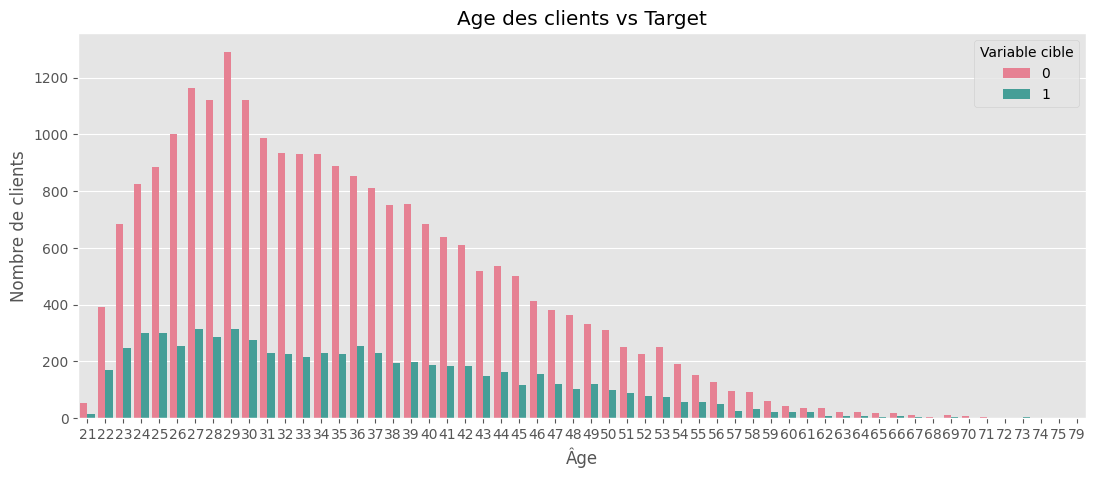

In [31]:
plt.figure(figsize=(13, 5))
sns.countplot(x='AGE', hue='default.payment.next.month', data=data, palette='husl')
plt.title('Age des clients vs Target')
plt.xlabel('Âge')
plt.ylabel('Nombre de clients')
plt.legend(title='Variable cible', loc='upper right')
plt.show()

> Les clients de 60 ans ont le taux le plus élevé de défaut de paiement (34.3%), tandis que pour les autres le taux de défaut varie entre 20% et 30%.
Les clients plus âgés semblent avoir un risque de défaut de paiement plus élevé que les clients plus jeunes
> 
> Les individus âgés de 20 à 30 ans, ainsi que ceux de plus de 50 ans, ont tendance à être plus susceptibles de faire défaut sur leurs paiements par carte de crédit. En revanche, les individus dans d'autres tranches d'âge montrent des tendances moins prononcées au défaut.

In [32]:
pip install scipy


Note: you may need to restart the kernel to use updated packages.


# Test ANOVA 
* H0 (hypothèse nulle): Les moyennes de tous les groupes sont égales.
* H1 (hypothèse alternative): Au moins une des moyennes des groupes est différente des autres.

In [33]:
#AGE ET TARGET

from scipy.stats import f_oneway

# Créer des groupes basés sur la variable cible (target)
grouped_data = [data['AGE'][data['default.payment.next.month'] == category] for category in data['default.payment.next.month'].unique()]

# Afficher la taille de chaque groupe
for i, group in enumerate(grouped_data):
    print(f"Taille du groupe {i+1} : {len(group)}")

# Effectuer le test ANOVA
f_statistic, p_value = f_oneway(*grouped_data)

# Afficher les résultats
print(f"Statistique du test ANOVA : {f_statistic}")
print(f"P-valeur : {p_value}")

Taille du groupe 1 : 6636
Taille du groupe 2 : 23364
Statistique du test ANOVA : 5.7885558246720565
P-valeur : 0.016136845890286453


> ->  les âges peuvent varier en fonction du défaut de paiement des clients.
> La variable AGE affecte la variable cible ,elles sont dépendantes .
> > 

# LIMIT_BAL VS Target

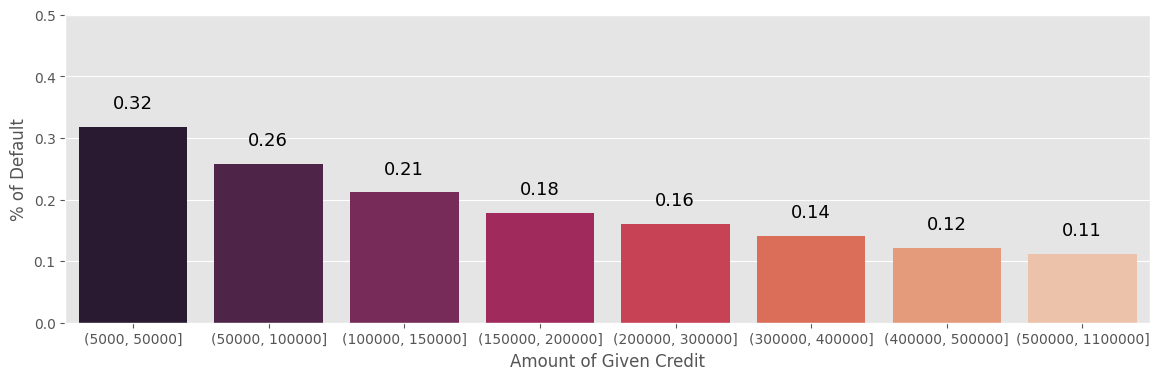

In [34]:
data['LimitBin'] = pd.cut(data['LIMIT_BAL'],[5000, 50000, 100000, 150000, 200000, 300000, 400000, 500000, 1100000])
data['LimitBin'] = data['LimitBin'].astype('str')
LimitBin_order = ['(5000, 50000]', '(50000, 100000]', '(100000, 150000]', '(150000, 200000]',
                '(200000, 300000]', '(300000, 400000]', '(400000, 500000]', '(500000, 1100000]']

plt.figure(figsize=(14,4))

ax = sns.barplot(x = "LimitBin", y = "default.payment.next.month", data = data, palette = 'rocket', errorbar = None, order = LimitBin_order)

plt.xlabel("Amount of Given Credit", fontsize= 12)
plt.ylabel("% of Default", fontsize= 12)
plt.ylim(0,0.5)

for p in ax.patches:
    ax.annotate("%.2f" %(p.get_height()), (p.get_x()+0.25, p.get_height()+0.03),fontsize=13)

plt.show()

> -> Il y a un taux de défaut significatif (plus de 30 %) chez les clients avec 50 000 dollars NT ou moins de limite de crédit.
> 
> -> Plus la limite est élevée, plus le risque de défaut est faible.

In [35]:
# Diviser les données en groupes en fonction de la variable cible
grouped_data = [data['LIMIT_BAL'][data['default.payment.next.month'] == 0],
                data['LIMIT_BAL'][data['default.payment.next.month'] == 1]]

# Effectuer le test ANOVA
anova_result = f_oneway(*grouped_data)

# Afficher les résultats
print("Statistique du test ANOVA :", anova_result.statistic)
print("P-valeur :", anova_result.pvalue)

Statistique du test ANOVA : 724.0685392611651
P-valeur : 1.3022439532706416e-157


> Le test ANOVA montre une différence significative dans les montants de crédit (LIMIT_BAL) entre les clients qui ont un défaut de paiement et ceux qui n'en ont pas.
> -> La variable LIMIT_BAL affecte la variable cible ,elles sont dépendantes .


# Les PAY_i VS Target 

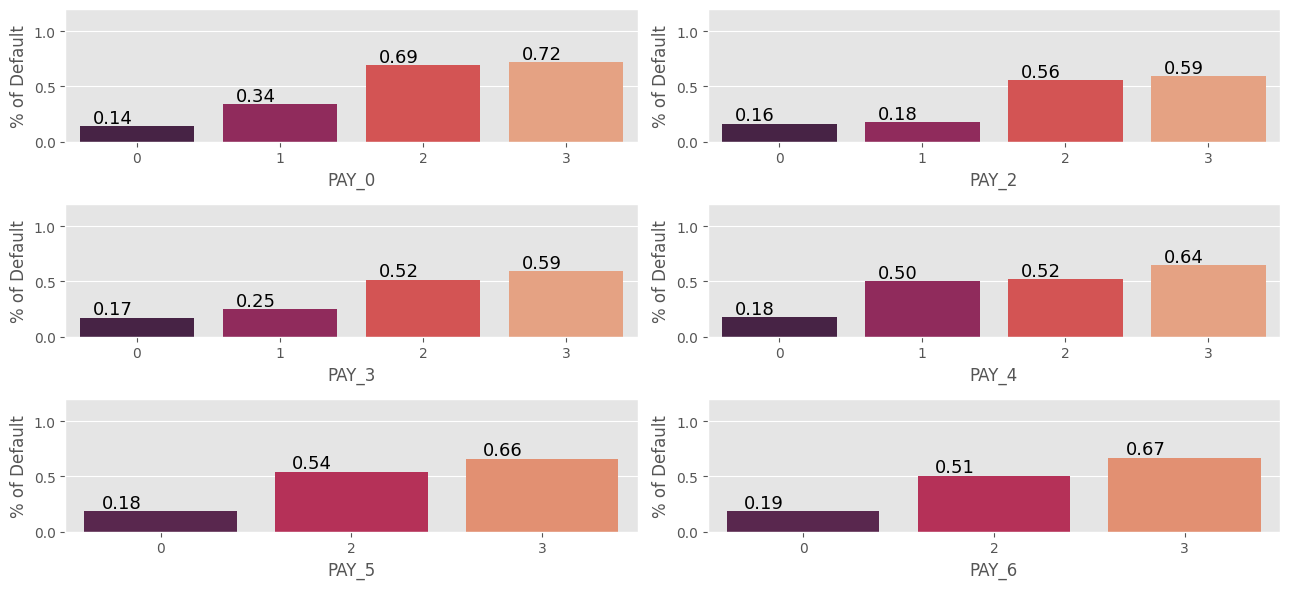

In [36]:
pay_x_fts = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
plt.figure(figsize=(13, 6))

for i, col in enumerate(pay_x_fts):    
    plt.subplot(3, 2, i + 1)
    ax = sns.barplot(x=col, y="default.payment.next.month", data=data, palette='rocket', errorbar=None)
    plt.ylabel("% of Default", fontsize=12)
    plt.ylim(0, 1.2)
    plt.tight_layout()
    
    for p in ax.patches:
        ax.annotate("%.2f" % (p.get_height()), (p.get_x() + 0.09, p.get_height() + 0.03), fontsize=13)

plt.show()

> -->Les taux de défaut de paiement ont tendance à augmenter à mesure que la valeur de PAY_i devient plus positive. Les clients avec des retards de paiement plus longs ont un risque plus élevé de défaut.

#  Test du chi-carré (chi2)
* H0 (hypothèse nulle):  les deux variables sont indépendantes..
* H1 (hypothèse alternative):  les deux variables sont dépendantes.

In [37]:
from scipy.stats import chi2_contingency

# Sélectionner les colonnes PAY_i et la variable cible
pay_columns = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
target_variable = 'default.payment.next.month'

# Effectuer le test du chi2 pour chaque colonne PAY_i
for col in pay_columns:
    contingency_table = pd.crosstab(data[col], data[target_variable])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency_table)
    print(f"Test du Chi2 pour {col}:")
    print(f"Statistique du Chi2 : {chi2_stat}")
    print(f"P-valeur : {p_val}")
    print()

Test du Chi2 pour PAY_0:
Statistique du Chi2 : 5312.976180794414
P-valeur : 0.0

Test du Chi2 pour PAY_2:
Statistique du Chi2 : 3454.9248244242367
P-valeur : 0.0

Test du Chi2 pour PAY_3:
Statistique du Chi2 : 2600.3719396236856
P-valeur : 0.0

Test du Chi2 pour PAY_4:
Statistique du Chi2 : 2303.8350599325286
P-valeur : 0.0

Test du Chi2 pour PAY_5:
Statistique du Chi2 : 2162.8568790094005
P-valeur : 0.0

Test du Chi2 pour PAY_6:
Statistique du Chi2 : 1860.917029842899
P-valeur : 0.0



> Les résultats des tests du chi2 suggèrent fortement une dépendance entre les variables PAY_i et la variable cible .
> La façon dont les clients ont payé leurs factures précédentes est liée à la probabilité qu'ils ne paient pas leurs factures dans le futur. 


> les états de paiement sont généralement corrélés positivement entre eux, ce qui signifie que si un état de paiement est en retard, il est probable que les états de paiement suivants le soient aussi.

# BILL_AMT_i VS Target

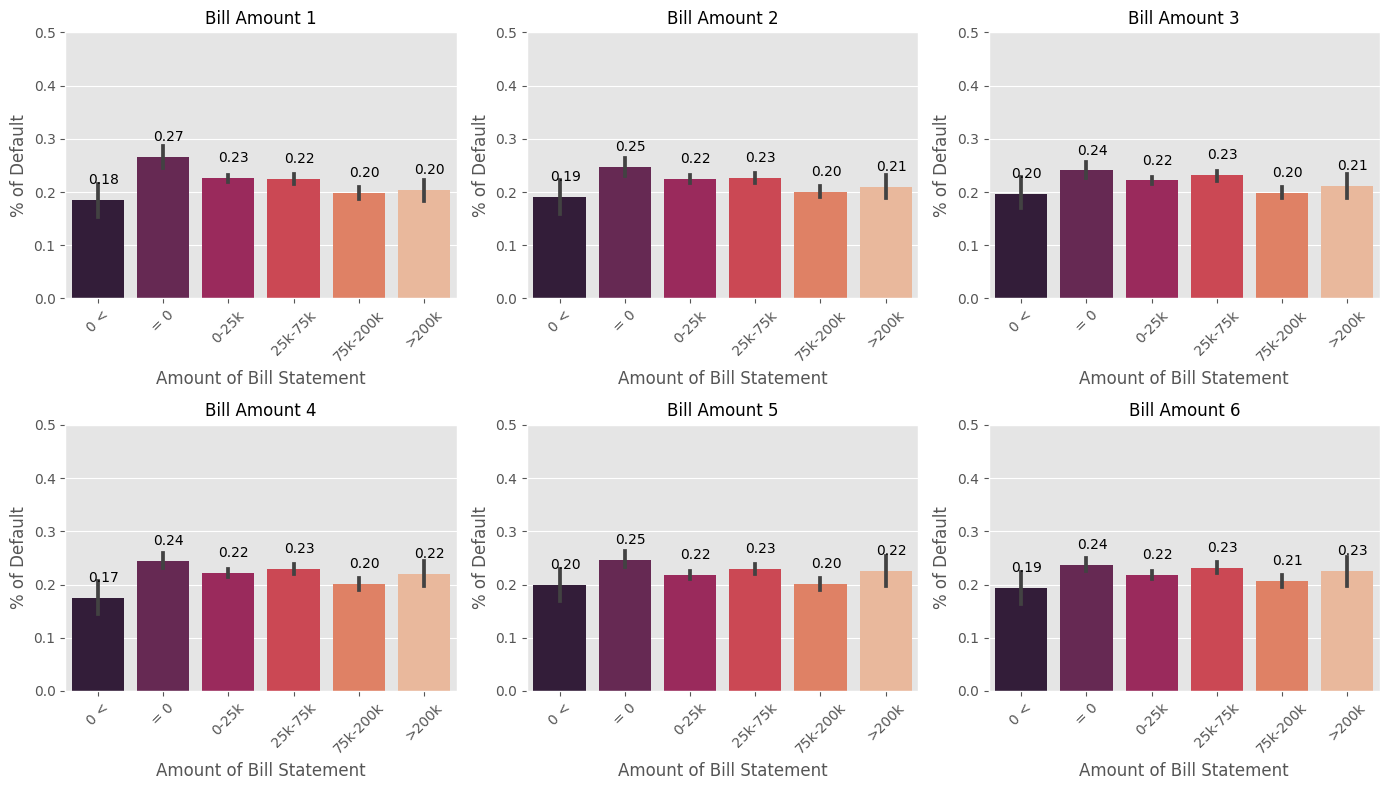

In [38]:
bill_amt_columns = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
bin_labels = ['0 <', '= 0', '0-25k', '25k-75k', '75k-200k', '>200k']

for col in bill_amt_columns:
    data[f'{col}_Bin'] = pd.cut(data[col], [-350000, -1, 0, 25000, 75000, 200000, 2000000], labels=bin_labels)
    data[f'{col}_Bin'] = data[f'{col}_Bin'].astype('str')

plt.figure(figsize=(14, 8))

for i, col in enumerate(bill_amt_columns, 1):
    plt.subplot(2, 3, i)
    ax = sns.barplot(x=f"{col}_Bin", y="default.payment.next.month", data=data, palette='rocket', order=bin_labels)
    plt.xlabel("Amount of Bill Statement", fontsize=12)
    plt.ylabel("% of Default", fontsize=12)
    plt.ylim(0, 0.5)
    plt.title(f"Bill Amount {i}", fontsize=12)
    plt.xticks(rotation=45)
    for p in ax.patches:
        ax.annotate("%.2f" % (p.get_height()), (p.get_x() + 0.25, p.get_height() + 0.03), fontsize=10)

plt.tight_layout()
plt.show()

> Ceux qui ont un relevé de facture négatif ont moins de chances de défaut que les autres. , Il y a un taux de défaut plus élevé parmi ceux qui n'ont rien payé dans les mois précédents et des taux plus bas parmi ceux qui ont payé plus de 25 000 dollars NT.

**Anova test**

In [39]:
bill_amtx_fts = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# Créer un sous-ensemble du DataFrame avec les colonnes 'BILL_AMT_i' et 'default.payment.next.month'
subset_data = data[bill_amtx_fts + ['default.payment.next.month']]

# Effectuer le test ANOVA pour chaque colonne 'BILL_AMT_i'
anova_results = {}

for col in bill_amtx_fts:
    groups = [subset_data[subset_data['default.payment.next.month'] == 0][col],
              subset_data[subset_data['default.payment.next.month'] == 1][col]]

    anova_result = f_oneway(*groups)
    anova_results[col] = {'F-statistic': anova_result.statistic, 'p-value': anova_result.pvalue}

# Afficher les résultats
for col, result in anova_results.items():
    print(f"ANONA pour {col} - F-statistic: {result['F-statistic']}, p-value: {result['p-value']}")

ANONA pour BILL_AMT1 - F-statistic: 11.58053151629362, p-value: 0.0006673295491269827
ANONA pour BILL_AMT2 - F-statistic: 6.044237892358568, p-value: 0.013957362392557893
ANONA pour BILL_AMT3 - F-statistic: 5.944387708459894, p-value: 0.014769982710844272
ANONA pour BILL_AMT4 - F-statistic: 3.0947451847823078, p-value: 0.07855564157726781
ANONA pour BILL_AMT5 - F-statistic: 1.3710873966293116, p-value: 0.24163444291518688
ANONA pour BILL_AMT6 - F-statistic: 0.8658202918873876, p-value: 0.35212252122434606


> *  BILL_AMT1 est la seule variable qui montre une dépendance significative avec la variable cible
> * Les ( BILL_AMT2 , BILL_AMT3 ,BILL_AMT4, BILL_AMT5, BILL_AMT6) ne montrent pas de différences significatives entre les clients qui ont fait défaut et ceux qui n'ont pas fait défaut. Par conséquent, ces variables ne sont pas dépendantes de la variable cible.

# PAY_AMT1_i VS Target

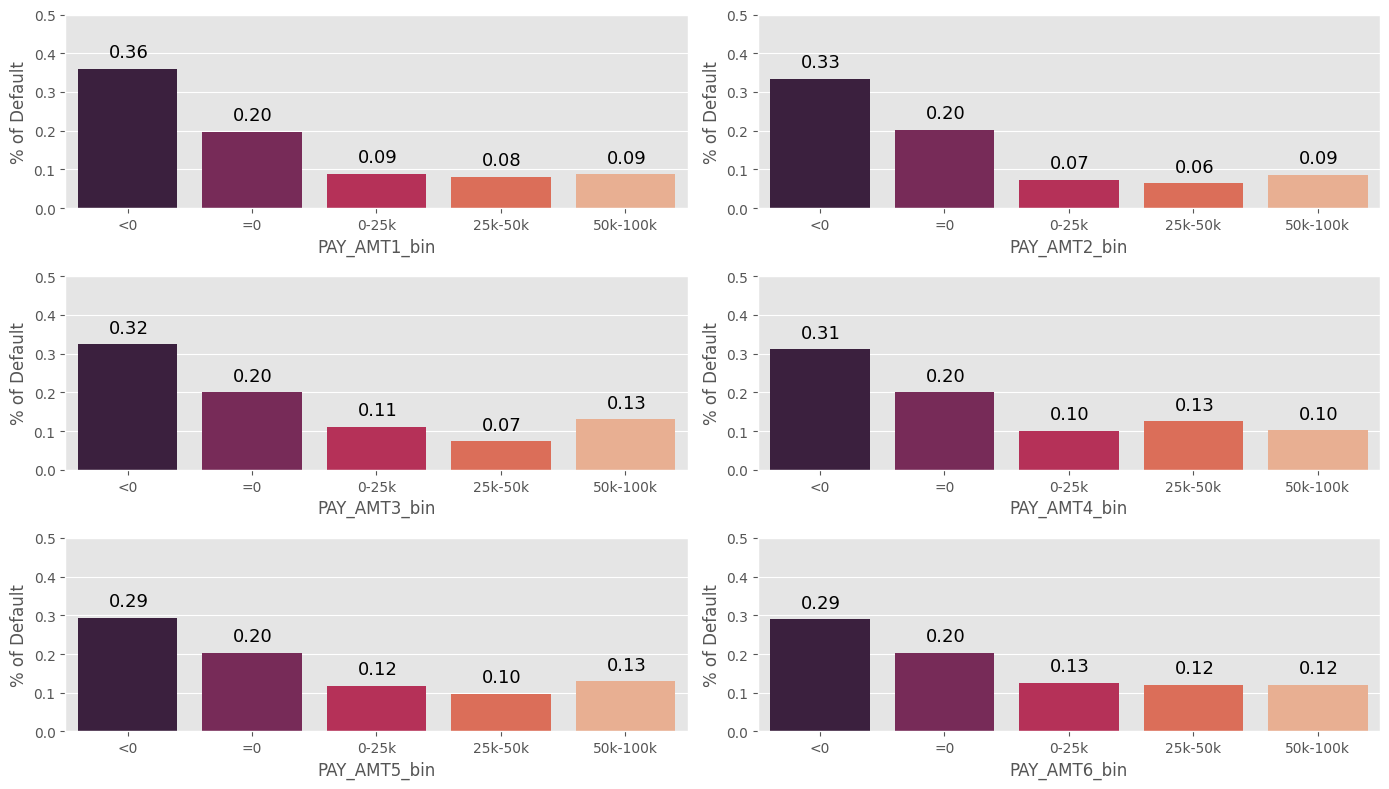

In [40]:
pay_amt_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
pay_amtx_bins = ['PAY_AMT1_bin', 'PAY_AMT2_bin', 'PAY_AMT3_bin', 'PAY_AMT4_bin', 'PAY_AMT5_bin', 'PAY_AMT6_bin']
bin_labels = ['<0', '=0', '0-25k', '25k-50k', '50k-100k']
bin_edges = [-1, 0, 25000, 50000, 100000, 2000000]

plt.figure(figsize=(14, 8))

for i, col in enumerate(pay_amt_columns):
    data[pay_amtx_bins[i]] = pd.cut(data[col], bins=bin_edges, labels=bin_labels)

for i, col in enumerate(pay_amtx_bins, 1):
    plt.subplot(3, 2, i)
    ax = sns.barplot(x=col, y="default.payment.next.month", data=data, palette='rocket', errorbar=None)
    plt.ylabel("% of Default", fontsize=12)
    plt.ylim(0, 0.5)
    plt.tight_layout()

    for p in ax.patches:
        ax.annotate("%.2f" % (p.get_height()), (p.get_x() + 0.25, p.get_height() + 0.03), fontsize=13)

plt.show()

> -> Il y a un taux de défaut plus élevé parmi ceux qui n'ont rien payé dans les mois précédents et des taux plus bas parmi ceux qui ont payé plus de 25 000 dollars NT.

**Anova test**

In [41]:
Pay_amtx_fts = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# Créer un sous-ensemble du DataFrame avec les colonnes 'BILL_AMT_i' et 'default.payment.next.month'
subset_data = data[Pay_amtx_fts + ['default.payment.next.month']]

# Effectuer le test ANOVA pour chaque colonne 'PAY_AMT_i'
anova_results = {}

for col in Pay_amtx_fts:
    groups = [subset_data[subset_data['default.payment.next.month'] == 0][col],
              subset_data[subset_data['default.payment.next.month'] == 1][col]]

    anova_result = f_oneway(*groups)
    anova_results[col] = {'F-statistic': anova_result.statistic, 'p-value': anova_result.pvalue}

# Afficher les résultats
for col, result in anova_results.items():
    print(f"ANONA pour {col} - F-statistic: {result['F-statistic']}, p-value: {result['p-value']}")

ANONA pour PAY_AMT1 - F-statistic: 160.4038095819619, p-value: 1.1464876142332767e-36
ANONA pour PAY_AMT2 - F-statistic: 103.29152425436158, p-value: 3.1666567628704887e-24
ANONA pour PAY_AMT3 - F-statistic: 95.21801088949971, p-value: 1.8417702915181029e-22
ANONA pour PAY_AMT4 - F-statistic: 97.188000468963, p-value: 6.830941601431493e-23
ANONA pour PAY_AMT5 - F-statistic: 91.42980080214153, p-value: 1.2413447727883624e-21
ANONA pour PAY_AMT6 - F-statistic: 85.08904532729825, p-value: 3.0335890727980635e-20


>  Tous les PAY_AMT_i, à savoir PAY_AMT1, PAY_AMT2, PAY_AMT3, PAY_AMT4, PAY_AMT5 et PAY_AMT6, sont significativement associés à la variable cible , comme indiqué par les valeurs de p très faibles.

In [42]:
columns_to_drop = ['LimitBin', 'BILL_AMT1_Bin', 'BILL_AMT2_Bin', 'BILL_AMT3_Bin', 
                   'BILL_AMT4_Bin', 'BILL_AMT5_Bin', 'BILL_AMT6_Bin', 'PAY_AMT1_bin', 
                   'PAY_AMT2_bin', 'PAY_AMT3_bin', 'PAY_AMT4_bin', 'PAY_AMT5_bin', 
                   'PAY_AMT6_bin']

data.drop(columns=columns_to_drop, inplace=True)


In [43]:
data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,0,0,0,0,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,0,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,0,0,0,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


# Sélection basée sur l'information value

**Interprétation de l'Information Value :**

* IV < 0.02 : La variable a très peu de pouvoir prédictif.
* 0.02 <= IV < 0.1 : La variable a un faible pouvoir prédictif.
* 0.1 <= IV < 0.3 : La variable a un pouvoir prédictif moyen.
* 0.3 <= IV < 0.5 : La variable a un pouvoir prédictif fort.
* IV >= 0.5 : La variable a un pouvoir prédictif très fort, mais cela peut indiquer une fuite d'informations (data leakage) ou un problème avec les données.

In [44]:
def iv_woe(data, target, bins=20, show_woe=False, epsilon=1e-6):
    # Empty Dataframe
    newDF, woeDF = pd.DataFrame(), pd.DataFrame()
    
    # Extract Column Names
    cols = data.columns
    
    # Columns to exclude
    exclude_cols = [target, 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'EDUCATION', 'SEX', 'MARRIAGE','ID']
    
    # Run WOE and IV on quantitative independent variables
    for ivars in cols[~cols.isin(exclude_cols)]:
        if (data[ivars].dtype.kind in 'bifc') and (len(np.unique(data[ivars])) > 20):
            # For continuous variables with more than 20 unique values, use quantiles for binning
            binned_x = pd.qcut(data[ivars], bins, duplicates='drop')
            d0 = pd.DataFrame({'x': binned_x, 'y': data[target]})
        else:
            # For other quantitative variables, use the variable as it is
            d0 = pd.DataFrame({'x': data[ivars], 'y': data[target]})

        # Calculate the number of events in each group (bin)
        d = d0.groupby("x", as_index=False).agg({"y": ["count", "sum"]})
        d.columns = ['Cutoff', 'N', 'Events']

        # Calculate % of events in each group
        d['% of Events'] = np.maximum(d['Events'], epsilon) / (d['Events'].sum() + epsilon)

        # Calculate the non-events in each group
        d['Non-Events'] = d['N'] - d['Events']
        # Calculate % of non-events in each group
        d['% of Non-Events'] = np.maximum(d['Non-Events'], epsilon) / (d['Non-Events'].sum() + epsilon)

        # Calculate WOE by taking the natural log of the division of % of non-events and % of events
        d['WoE'] = np.log(d['% of Events'] / d['% of Non-Events'])
        d['IV'] = d['WoE'] * (d['% of Events'] - d['% of Non-Events'])
        
        # Calculate default rate
        d['Default Rate'] = d['Events'] / d['N']

        d.insert(loc=0, column='Variable', value=ivars)
        print("Information value of " + ivars + " is " + str(round(d['IV'].sum(), 6)))
        temp = pd.DataFrame({"Variable": [ivars], "IV": [d['IV'].sum()]}, columns=["Variable", "IV"])
        newDF = pd.concat([newDF, temp], axis=0)
        woeDF = pd.concat([woeDF, d], axis=0)

        # Show WOE Table
        if show_woe == True:
            print(d)
    return newDF, woeDF
v_results, woe_results = iv_woe(data, 'default.payment.next.month', bins=20, show_woe=True)

Information value of LIMIT_BAL is 0.180209
     Variable                 Cutoff     N  Events  % of Events  Non-Events  \
0   LIMIT_BAL    (9999.999, 20000.0]  2471     895     0.134870        1576   
1   LIMIT_BAL     (20000.0, 30000.0]  1610     568     0.085594        1042   
2   LIMIT_BAL     (30000.0, 50000.0]  3595     977     0.147227        2618   
3   LIMIT_BAL     (50000.0, 70000.0]  1556     443     0.066757        1113   
4   LIMIT_BAL     (70000.0, 80000.0]  1567     363     0.054702        1204   
5   LIMIT_BAL    (80000.0, 100000.0]  1699     438     0.066004        1261   
6   LIMIT_BAL   (100000.0, 120000.0]  1314     311     0.046866        1003   
7   LIMIT_BAL   (120000.0, 140000.0]  1478     327     0.049277        1151   
8   LIMIT_BAL   (140000.0, 160000.0]  1804     324     0.048825        1480   
9   LIMIT_BAL   (160000.0, 180000.0]  1527     254     0.038276        1273   
10  LIMIT_BAL   (180000.0, 200000.0]  1757     319     0.048071        1438   
11  LIMIT

In [45]:
def calculate_statistics_with_new_intervals(data, target, variable_intervals, woe_results):
    new_woeDF = pd.DataFrame()
    

    for variable, intervals in variable_intervals.items():
        iv_sum = 0  
        for interval in intervals:
            interval_data = data[(data[variable] >= interval[0]) & (data[variable] < interval[1])]
            event_total = interval_data[target].sum()
            non_event_total = interval_data.shape[0] - event_total

            total_event = data[target].sum()
            total_non_event = data.shape[0] - total_event

            event_pct = (event_total + 0.5) / (total_event + 0.5)
            non_event_pct = (non_event_total + 0.5) / (total_non_event + 0.5)

            woe = np.log(event_pct / non_event_pct)
            iv = (event_pct - non_event_pct) * woe
            iv_sum += iv  

            default_rate = event_total / interval_data.shape[0]

            new_woeDF = pd.concat([new_woeDF, pd.DataFrame({'Variable': [variable],
                                                            'Cutoff': [interval],
                                                            'WoE': [woe],
                                                            'IV': [iv],
                                                            'N': [interval_data.shape[0]],
                                                            'Events': [event_total],
                                                            'Non-events': [non_event_total],
                                                            '% Events': [event_pct],
                                                            '% Non-events': [non_event_pct],
                                                            'Default Rate': [default_rate]})])
        print(f"IV_sum for {variable}: {iv_sum}")  

    return new_woeDF
variable_intervals = {
        'LIMIT_BAL': [[9999.999, 30000.0], [30000.0, 1000000]],
        'AGE': [[20, 25], [25,  79]],
   
        'BILL_AMT1': [[-165580.001, 800.85], [800.85, 964511.0]],
        'BILL_AMT2': [[-69777.001, 12799.6], [12799.6,  983931.0]],
        'BILL_AMT3': [[-157264.001, 2666.25], [2666.25, 12197.2], [12197.2,  1664089.0]],
        'BILL_AMT4': [[-170000.001, 988.0], [988.0, 15613.65], [15613.65,  891586.0]],
        'BILL_AMT5': [[-81334.001, 9809.2], [9809.2, 50190.5], [50190.5, 927171.0]],
        'BILL_AMT6': [[-339603.001,  49198.25], [49198.25, 961664.0]],
        'PAY_AMT1': [[-0.001, 316.0], [316.0, 873552.0]],
        'PAY_AMT2': [[-0.001, 1600.0], [1600.0, 1684259.0]],
        'PAY_AMT3': [[-0.001, 2.8], [2.8, 2000.0], [2000.0, 896040.0]],
        'PAY_AMT4': [[-0.001, 1500.0], [1500.0, 621000.0]],
        'PAY_AMT5': [[-0.001, 2000.0], [2000.0, 426529.0]],
        'PAY_AMT6': [[-0.001, 2000.0], [2000.0, 528666.0]]
    }

# Exemple d'utilisation :
new_woe_results = calculate_statistics_with_new_intervals(data, 'default.payment.next.month', variable_intervals, woe_results)
print(new_woe_results)

IV_sum for LIMIT_BAL: 0.0518055249339054
IV_sum for AGE: 0.007991289378009574
IV_sum for BILL_AMT1: 0.0036814043233633696
IV_sum for BILL_AMT2: 0.00016431017744396862
IV_sum for BILL_AMT3: 0.002877334252412098
IV_sum for BILL_AMT4: 0.004686292550183995
IV_sum for BILL_AMT5: 0.008609997185621467
IV_sum for BILL_AMT6: 0.0021383218615501944
IV_sum for PAY_AMT1: 0.1123405438659936
IV_sum for PAY_AMT2: 0.07966333928392427
IV_sum for PAY_AMT3: 0.10078971319274144
IV_sum for PAY_AMT4: 0.05920274104895218
IV_sum for PAY_AMT5: 0.05811111663461651
IV_sum for PAY_AMT6: 0.0642386919453947
    Variable                   Cutoff       WoE        IV      N  Events  \
0  LIMIT_BAL      [9999.999, 30000.0]  0.693053  0.046754   2471     895   
0  LIMIT_BAL       [30000.0, 1000000] -0.074983  0.005051  27528    5741   
0        AGE                 [20, 25]  0.273961  0.007226   2685     730   
0        AGE                 [25, 79] -0.029102  0.000765  27314    5906   
0  BILL_AMT1    [-165580.001, 800.85

> 
* La variable LIMIT_BAL a un IV d'environ 0.13, ce qui signifie qu'elle a un pouvoir prédictif moyen.
* L'âge (AGE) a un IV d'environ 0.02, indiquant un pouvoir prédictif très faible.
* Les variables BILL_AMT1 à BILL_AMT6 ont toutes un IV inférieur à 0.02, ce qui suggère qu'elles ont très peu de pouvoir prédictif.
* Les variables PAY_AMT1 et PAY_AMT3 ont un IV enciron 0.1 ,  ce qui signifie qu'elles ont un pouvoir prédictif moyen.
* Les autres PAY_AMT2 , PAY_AMT4, PAY_AMT5 , PAY_AMT6 ont un faible pouvoir prédictif.

In [46]:
def iv_woe(data, target, show_woe=False, epsilon=1e-6):
    # Empty Dataframe
    newDF, woeDF = pd.DataFrame(), pd.DataFrame()
    
    # Extract Column Names
    cols = data.columns
    
    # Columns to exclude
    exclude_cols = [target,'AGE', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'BILL_AMT1', 'BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5', 'BILL_AMT6', 'LIMIT_BAL','ID','Credit_Class']
    
    # Run WOE and IV on qualitative independent variables
    for ivars in cols[~cols.isin(exclude_cols)]:
        # Compute WoE and IV
        grouped = data.groupby(ivars).agg({target: ['count', 'sum']})
        grouped.columns = ['N', 'Events']
        
        # Calculate % of events in each group
        grouped['% of Events'] = np.maximum(grouped['Events'], epsilon) / (grouped['Events'].sum() + epsilon)
        
        # Calculate the non-events in each group
        grouped['Non-Events'] = grouped['N'] - grouped['Events']
        
        # Calculate % of non-events in each group
        grouped['% of Non-Events'] = np.maximum(grouped['Non-Events'], epsilon) / (grouped['Non-Events'].sum() + epsilon)
        
        # Calculate WOE by taking the natural log of the division of % of non-events and % of events
        grouped['WoE'] = np.log(grouped['% of Events'] / grouped['% of Non-Events'])
        
        # Calculate IV
        grouped['IV'] = grouped['WoE'] * (grouped['% of Events'] - grouped['% of Non-Events'])
        
        # Calculate default rate
        grouped['Default Rate'] = grouped['Events'] / grouped['N']
        
        grouped.insert(loc=0, column='Variable', value=ivars)
        
        print("Information value of " + ivars + " is " + str(round(grouped['IV'].sum(), 6)))
        
        temp = pd.DataFrame({"Variable": [ivars], "IV": [grouped['IV'].sum()]}, columns=["Variable", "IV"])
        newDF = pd.concat([newDF, temp], axis=0)
        woeDF = pd.concat([woeDF, grouped], axis=0)
        
        # Show WOE Table
        if show_woe:
            print(grouped)
    
    return newDF, woeDF 

# Exemple d'utilisation de la fonction
v_results, woe_results = iv_woe(data, 'default.payment.next.month', show_woe=True)

Information value of SEX is 0.00918
    Variable      N  Events  % of Events  Non-Events  % of Non-Events  \
SEX                                                                     
1        SEX  11888    2873     0.432942        9015          0.38585   
2        SEX  18112    3763     0.567058       14349          0.61415   

          WoE        IV  Default Rate  
SEX                                    
1    0.115154  0.005423      0.241672  
2   -0.079777  0.003757      0.207763  
Information value of EDUCATION is 0.037299
            Variable      N  Events  % of Events  Non-Events  % of Non-Events  \
EDUCATION                                                                       
1          EDUCATION  10585    2036     0.306811        8549         0.365905   
2          EDUCATION  14030    3330     0.501808       10700         0.457970   
3          EDUCATION   4917    1237     0.186407        3680         0.157507   
4          EDUCATION    468      33     0.004973         435   

> *  La variable "SEX" a un IV de 0.00918, ce qui signifie qu'elle a un très faible pouvoir prédictif.
> * La variable "EDUCATION" a un IV de 0.046782, ce qui indique également un pouvoir prédictif faible.
> * La variable "MARRIAGE" a un IV de 0.007235, ce qui signifie qu'elle a un très faible pouvoir prédictif.
> * Les variables "PAY_0" et "PAY_2" ont un pouvoir prédictif fort.
> * Les variables "PAY_3" à "PAY_6" ont un pouvoir prédictif moyen.

> **Les variables explicatives selon l'IV sont** : LIMIT_BAL , PAY_AMT1 , PAY_AMT3 ,PAY_0, PAY_2 , PAY_3, PAY_4, PAY_5 et PAY_6

Coefficient V de Cramer entre chaque paire de variables :
          PAY_0     PAY_2     PAY_3     PAY_4     PAY_5     PAY_6
PAY_0       nan  0.443128  0.301786  0.288141  0.329402   0.29394
PAY_2  0.443128       nan  0.478254  0.341532  0.334054  0.295089
PAY_3  0.301786  0.478254       nan  0.604089  0.420366  0.375443
PAY_4  0.288141  0.341532  0.604089       nan  0.621413  0.492178
PAY_5  0.329402  0.334054  0.420366  0.621413       nan  0.625329
PAY_6   0.29394  0.295089  0.375443  0.492178  0.625329       nan


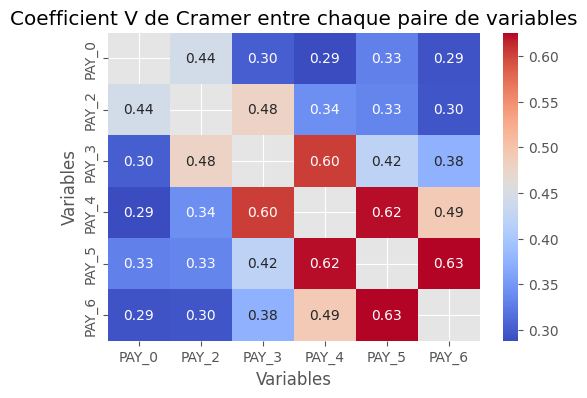

In [47]:
# Liste des variables catégorielles
variables = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# DataFrame pour stocker les résultats du coefficient V de Cramer
cramer_results = pd.DataFrame(index=variables, columns=variables)

# Calcul du coefficient V de Cramer entre chaque paire de variables
for var1 in variables:
    for var2 in variables:
        if var1 != var2:
            cross_tab = pd.crosstab(data[var1], data[var2])
            
            chi2, _, _, _ = chi2_contingency(cross_tab)
            
            n = cross_tab.sum().sum()
            min_dim = min(cross_tab.shape)
            v_cramer = (chi2 / (n * (min_dim - 1)))**0.5
            
            cramer_results.loc[var1, var2] = v_cramer

# Remplacement des valeurs NaN par 'nan'
cramer_results.replace(np.nan, 'nan', inplace=True)

# Affichage des résultats
print("Coefficient V de Cramer entre chaque paire de variables :")
print(cramer_results)
# Remplacement des valeurs NaN par des chaînes de caractères "nan"
cramer_results.replace(np.nan, '1', inplace=True)

# Conversion des valeurs de chaînes de caractères en nombres
cramer_results = cramer_results.apply(pd.to_numeric, errors='coerce')

# Création du plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cramer_results, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Coefficient V de Cramer entre chaque paire de variables")
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.show()

PAY_AMT1 est fortement corrélée à limit_bal et à pay_amt3

Pay_amt3 est fortement corrélée à pay_4

pay_amt4 est fortement corrélée à pay_5

pay_5 est fortement corrélée à pay_6


on va garder pay_0 , pay_2 , limit_bal , pay_3 , pay_amt4 , pay_5 , limit_bal , pay_amt3




In [48]:
data1=pd.DataFrame(woe_results)
data2=pd.DataFrame(new_woe_results)
new_woe_results = pd.DataFrame(new_woe_results)
new_woe_results.rename(columns={'Cutoff': 'N'}, inplace=True)


In [49]:
data1 

,Variable,N,Events,% of Events,Non-Events,% of Non-Events,WoE,IV,Default Rate
1,SEX,11888,2873,0.432942,9015,0.385850,0.115154,0.005423,0.241672
2,SEX,18112,3763,0.567058,14349,0.614150,-0.079777,0.003757,0.207763
1,EDUCATION,10585,2036,0.306811,8549,0.365905,-0.176140,0.010409,0.192348
2,EDUCATION,14030,3330,0.501808,10700,0.457970,0.091416,0.004008,0.237349
3,EDUCATION,4917,1237,0.186407,3680,0.157507,0.168463,0.004869,0.251576
4,EDUCATION,468,33,0.004973,435,0.018618,-1.320151,0.018014,0.070513
0,MARRIAGE,377,89,0.013412,288,0.012327,0.084363,0.000092,0.236074
1,MARRIAGE,13659,3206,0.483122,10453,0.447398,0.076822,0.002744,0.234717
2,MARRIAGE,15964,3341,0.503466,12623,0.540276,-0.070563,0.002597,0.209283
0,PAY_0,23182,3207,0.483273,19975,0.854948,-0.570459,0.212025,0.138340


In [50]:
data2

,Variable,Cutoff,WoE,IV,N,Events,Non-events,% Events,% Non-events,Default Rate
0,LIMIT_BAL,"[9999.999, 30000.0]",0.693053,0.046754,2471,895,1576,0.134936,0.067474,0.362202
0,LIMIT_BAL,"[30000.0, 1000000]",-0.074983,0.005051,27528,5741,21787,0.865140,0.932504,0.208551
0,AGE,"[20, 25]",0.273961,0.007226,2685,730,1955,0.110073,0.083695,0.271881
0,AGE,"[25, 79]",-0.029102,0.000765,27314,5906,21408,0.890002,0.916283,0.216226
0,BILL_AMT1,"[-165580.001, 800.85]",0.141270,0.003112,4500,1109,3391,0.167181,0.145156,0.246444
0,BILL_AMT1,"[800.85, 964511.0]",-0.025988,0.000570,25499,5527,19972,0.832894,0.854822,0.216754
0,BILL_AMT2,"[-69777.001, 12799.6]",-0.015659,0.000098,12000,2622,9378,0.395163,0.401400,0.218500
0,BILL_AMT2,"[12799.6, 983931.0]",0.010525,0.000067,17999,4014,13985,0.604912,0.598579,0.223012
0,BILL_AMT3,"[-157264.001, 2666.25]",0.036168,0.000330,7500,1706,5794,0.257139,0.248004,0.227467
0,BILL_AMT3,"[2666.25, 12197.2]",-0.128634,0.002393,4500,899,3601,0.135538,0.154144,0.199778


# **Model development**

In [51]:
data = data  
variables_to_keep = ['AGE','MARRIAGE','SEX','BILL_AMT1','PAY_0', 'PAY_2' , 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'LIMIT_BAL', 'PAY_AMT1', 'PAY_AMT3', 'EDUCATION', 'PAY_AMT2', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']
variables_to_transform = ['BILL_AMT1','LIMIT_BAL', 'PAY_AMT1', 'PAY_AMT3', 'PAY_AMT2', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
intervals_mapping = {
    'LIMIT_BAL': [[1000, 100000.0],[100000.0, 140000], [140000, 1000000]],
    'PAY_AMT1': [[-0.001, 316.0], [316.0, 873552.0]],
    'PAY_AMT3': [[-0.001, 2.8], [2.8, 2000.0], [2000.0, 896040.0]],
    'PAY_AMT2': [[-0.001, 1600.0], [1600.0, 1684259.0]],
    'PAY_AMT4': [[-0.001, 1500.0], [1500.0, 621000.0]],
    'PAY_AMT5': [[-0.001, 2000.0], [2000.0, 426529.0]],
    'PAY_AMT6': [[-0.001, 2000.0], [2000.0, 528666.0]],
    'BILL_AMT1': [[-165580.001, 800.85], [800.85, 964511.0]],
    'AGE':[[20,25],[25,79]]
}

def map_to_interval(value, intervals):
    for i, interval in enumerate(intervals):
        if interval[0] <= value <= interval[1]:
            return f'{i}'
    return None
new_data = data[variables_to_keep].copy()

for var in variables_to_transform:
    if var in intervals_mapping:
        new_data[var] = data[var].apply(lambda x: map_to_interval(x, intervals_mapping[var]))

for column in new_data.columns:
    if column not in variables_to_transform and column != 'default.payment.next.month':
        unique_values = new_data[column].unique()
        mapping = {value: f'{i}' for i, value in enumerate(unique_values)}
        new_data[column] = new_data[column].map(mapping)

new_data

,AGE,MARRIAGE,SEX,BILL_AMT1,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,LIMIT_BAL,PAY_AMT1,PAY_AMT3,EDUCATION,PAY_AMT2,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,1,1,0,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,1
2,2,1,0,1,1,1,0,0,0,0,0,1,1,0,0,0,0,1,0
3,3,0,0,1,1,1,0,0,0,0,0,1,1,0,1,0,0,0,0
4,4,0,1,1,1,1,0,0,0,0,0,1,2,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,13,0,1,1,1,1,0,0,0,0,2,1,2,2,1,1,1,0,0
29996,26,1,1,1,1,1,0,0,0,0,2,1,2,2,1,0,0,0,0
29997,3,1,1,1,3,2,1,0,0,0,0,0,2,0,0,1,0,1,1
29998,10,0,1,0,2,1,0,0,0,0,0,1,1,2,1,1,1,0,1


**1. Logistic Regression : Naive avec et sans scaling**

Logit model's accuracy: 0.7771666666666667
Gini Index: 0.30067747962885494
              precision    recall  f1-score   support

           0       0.78      1.00      0.87      4663
           1       1.00      0.00      0.00      1337

    accuracy                           0.78      6000
   macro avg       0.89      0.50      0.44      6000
weighted avg       0.83      0.78      0.68      6000



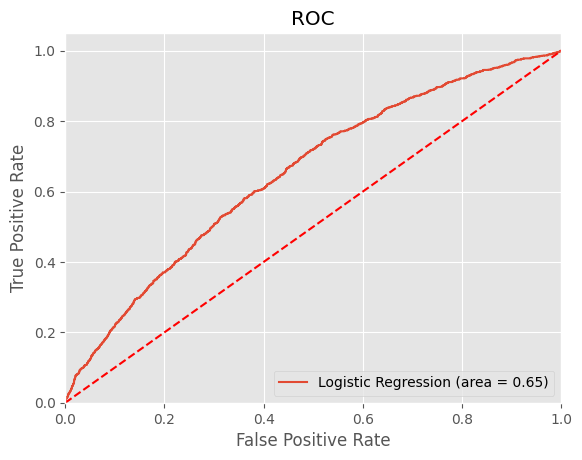

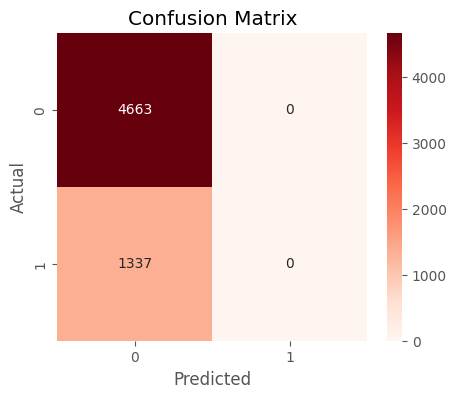

In [52]:
X = data.drop(['default.payment.next.month'], axis=1)
y = data['default.payment.next.month']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
 
logit = LogisticRegression(max_iter=1000)
logit.fit(X_train, y_train)

pred_logit = logit.predict(X_test)

print("Logit model's accuracy:", accuracy_score(y_test, pred_logit))


# Calcul de l'indice de Gini
y_pred_proba = logit.predict_proba(X_test)[:, 1]
gini_index = 2 * roc_auc_score(y_test, y_pred_proba) - 1
print("Gini Index:", gini_index)
print(classification_report(y_test, pred_logit, zero_division=1))

# Courbe ROC
area_under_curve = roc_auc_score(y_test, logit.predict_proba(X_test)[:, 1])
fpr, tpr, thresholds = roc_curve(y_test, logit.predict_proba(X_test)[:, 1])

plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % area_under_curve)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.legend(loc="lower right")
plt.show()

conf_matrix = confusion_matrix(y_test, pred_logit)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


**StandardScaler:**

Logit model's accuracy: 0.8218333333333333
Gini Index: 0.5283951334131374
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4663
           1       0.68      0.37      0.48      1337

    accuracy                           0.82      6000
   macro avg       0.76      0.66      0.69      6000
weighted avg       0.81      0.82      0.80      6000

Gini Index: 0.5283951334131374


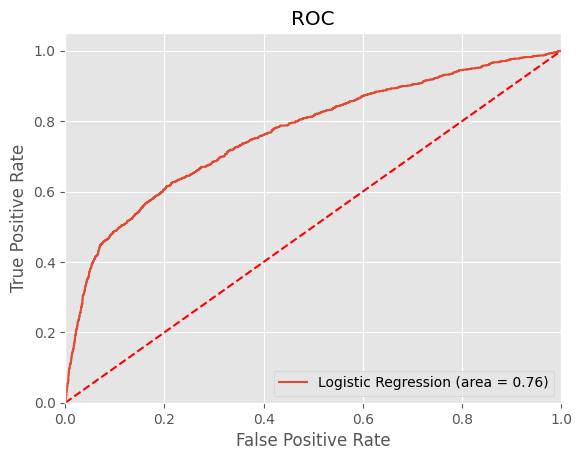

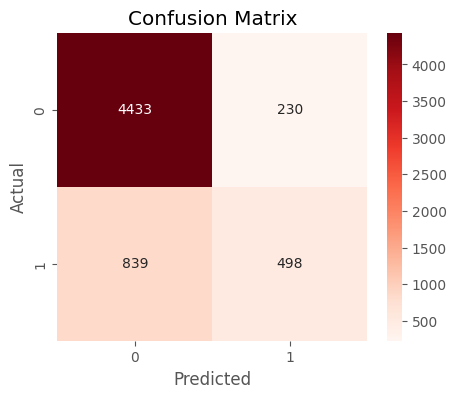

In [53]:
X = data.drop(['default.payment.next.month'], axis=1)
y = data['default.payment.next.month']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
logit = LogisticRegression()
logit.fit(X_train_scaled, y_train)
pred_logit = logit.predict(X_test_scaled)
print("Logit model's accuracy:", accuracy_score(y_test, pred_logit))
y_pred_proba = logit.predict_proba(X_test_scaled)[:, 1]
gini_index = 2 * roc_auc_score(y_test, y_pred_proba) - 1
print("Gini Index:", gini_index)

print(classification_report(y_test, pred_logit))

# Calculer l'indice de Gini
y_pred_proba = logit.predict_proba(X_test_scaled)[:, 1]
gini_index = 2 * roc_auc_score(y_test, y_pred_proba) - 1
print("Gini Index:", gini_index)

# Courbe ROC
area_under_curve = roc_auc_score(y_test, logit.predict_proba(X_test_scaled)[:, 1])
fpr, tpr, thresholds = roc_curve(y_test, logit.predict_proba(X_test_scaled)[:, 1])

plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % area_under_curve)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.legend(loc="lower right")
plt.show()

# Matrice de confusion
conf_matrix = confusion_matrix(y_test, pred_logit)

plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**MinMaxScaler**

In [54]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

logit = LogisticRegression()
logit.fit(X_train_scaled, y_train)

pred_logit = logit.predict(X_test_scaled)
# Calcul de l'accuracy pour chaque modèle
accuracy = accuracy_score(y_test, pred_logit)
print("Accuracy:", accuracy)
# Calcul de l'indice de Gini pour chaque modèle
y_pred_proba = logit.predict_proba(X_test_scaled)[:, 1]
gini_index = 2 * roc_auc_score(y_test, y_pred_proba) - 1
print("Gini Index:", gini_index)

Accuracy: 0.821
Gini Index: 0.5226011804445345


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**RobustScaler:**

In [55]:

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

logit = LogisticRegression(max_iter=1000)
logit.fit(X_train_scaled, y_train)

pred_logit = logit.predict(X_test_scaled)
accuracy = accuracy_score(y_test, pred_logit)
print("Accuracy:", accuracy)
y_pred_proba = logit.predict_proba(X_test_scaled)[:, 1]
gini_index = 2 * roc_auc_score(y_test, y_pred_proba) - 1
print("Gini Index:", gini_index)

Accuracy: 0.8218333333333333
Gini Index: 0.5284185517491491


**Rendre la data équilbrée**

In [56]:
df_smote = data.copy()

X = df_smote.drop(['default.payment.next.month'], axis=1)
y = df_smote['default.payment.next.month']

oversample = SMOTE();
X_resampled, y_resampled = oversample.fit_resample(X, y)

df_smote = pd.concat([X_resampled, y_resampled], axis=1)

print(df_smote['default.payment.next.month'].value_counts())

default.payment.next.month
1    23364
0    23364
Name: count, dtype: int64


Logit model's accuracy: 0.7250873814109423
Gini Index: 0.5856746586362302
              precision    recall  f1-score   support

           0       0.71      0.76      0.73      7005
           1       0.74      0.69      0.72      7014

    accuracy                           0.73     14019
   macro avg       0.73      0.73      0.72     14019
weighted avg       0.73      0.73      0.72     14019

Gini Index: 0.5856746586362302


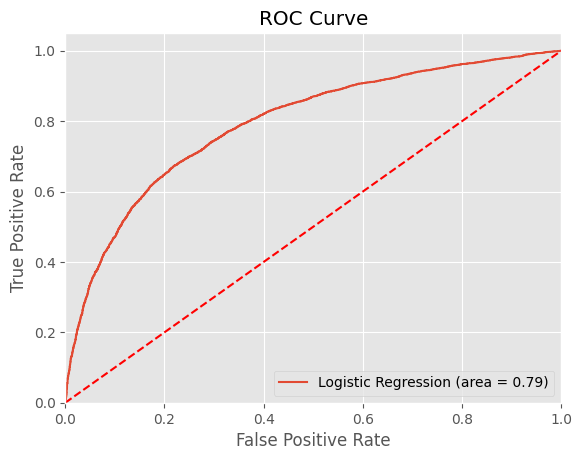

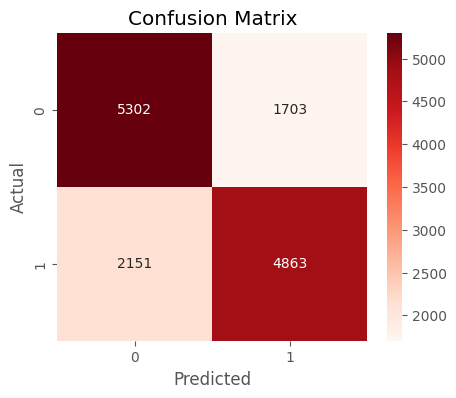

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

logit = LogisticRegression()

logit.fit(X_train_scaled, y_train)

pred_logit = logit.predict(X_test_scaled)

accuracy = accuracy_score(y_test, pred_logit)
print("Logit model's accuracy:", accuracy)
y_pred_proba = logit.predict_proba(X_test_scaled)[:, 1]
gini_index = 2 * roc_auc_score(y_test, y_pred_proba) - 1
print("Gini Index:", gini_index)
print(classification_report(y_test, pred_logit))

y_pred_proba = logit.predict_proba(X_test_scaled)[:, 1]
gini_index = 2 * roc_auc_score(y_test, y_pred_proba) - 1
print("Gini Index:", gini_index)

fpr, tpr, thresholds = roc_curve(y_test, logit.predict_proba(X_test_scaled)[:, 1])

plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % roc_auc_score(y_test, y_pred_proba))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

# Matrice de confusion
conf_matrix = confusion_matrix(y_test, pred_logit)

# Affichage de la matrice de confusion sous forme de heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**2. Logistic Regression(2) avec new_data**

Logit model's accuracy: 0.8024444444444444
Gini Index: 0.5019720784947233
              precision    recall  f1-score   support

           0       0.82      0.96      0.88      7003
           1       0.63      0.26      0.37      1997

    accuracy                           0.80      9000
   macro avg       0.73      0.61      0.63      9000
weighted avg       0.78      0.80      0.77      9000



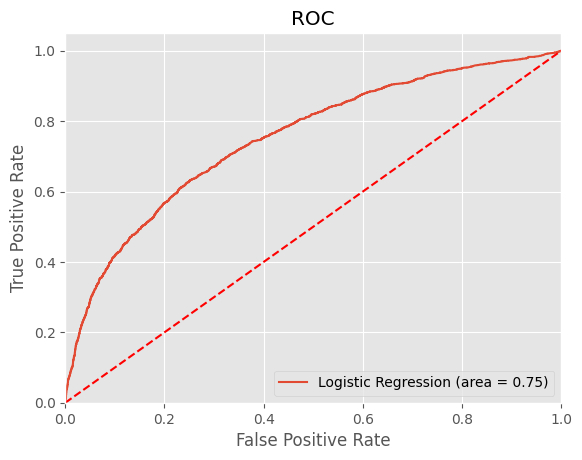

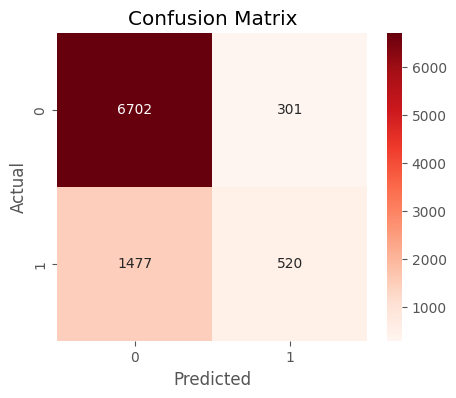

In [58]:
X = new_data.drop(['default.payment.next.month'], axis=1)
y = new_data['default.payment.next.month']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=20)
 
logit = LogisticRegression(max_iter=1000)
logit.fit(X_train, y_train)

pred_logit = logit.predict(X_test)

print("Logit model's accuracy:", accuracy_score(y_test, pred_logit))


# Calcul de l'indice de Gini
y_pred_proba = logit.predict_proba(X_test)[:, 1]
gini_index = 2 * roc_auc_score(y_test, y_pred_proba) - 1
print("Gini Index:", gini_index)
print(classification_report(y_test, pred_logit, zero_division=1))

# Courbe ROC
area_under_curve = roc_auc_score(y_test, logit.predict_proba(X_test)[:, 1])
fpr, tpr, thresholds = roc_curve(y_test, logit.predict_proba(X_test)[:, 1])

plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % area_under_curve)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.legend(loc="lower right")
plt.show()

conf_matrix = confusion_matrix(y_test, pred_logit)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Logit model's accuracy: 0.8001111111111111
              precision    recall  f1-score   support

           0       0.82      0.96      0.88      7040
           1       0.61      0.23      0.33      1960

    accuracy                           0.80      9000
   macro avg       0.71      0.59      0.61      9000
weighted avg       0.77      0.80      0.76      9000

Gini Index: 0.459346590909091


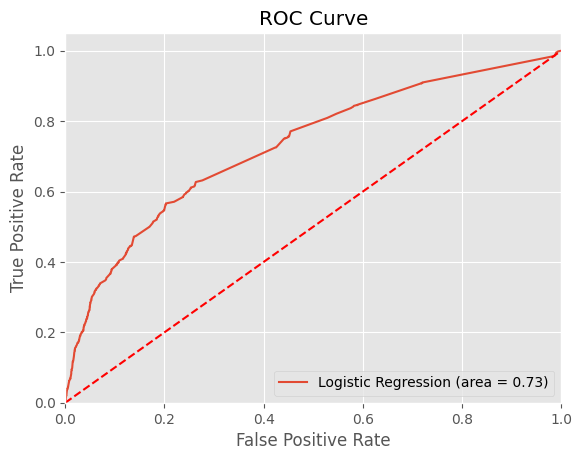

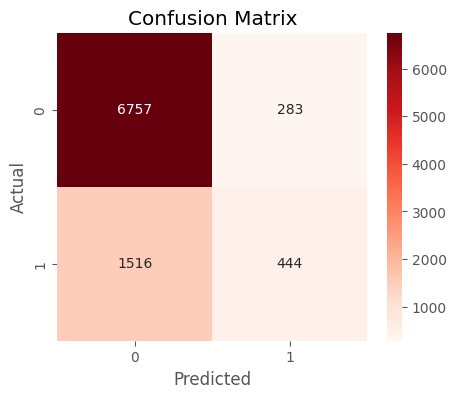

In [59]:
X = new_data[['LIMIT_BAL', 'PAY_AMT1', 'PAY_AMT3', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']]
y = new_data['default.payment.next.month']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

logit = LogisticRegression()

logit.fit(X_train, y_train)

pred_logit = logit.predict(X_test)

accuracy = accuracy_score(y_test, pred_logit)
print("Logit model's accuracy:", accuracy)

print(classification_report(y_test, pred_logit))

y_pred_proba = logit.predict_proba(X_test)[:, 1]
gini_index = 2 * roc_auc_score(y_test, y_pred_proba) - 1
print("Gini Index:", gini_index)

fpr, tpr, thresholds = roc_curve(y_test, logit.predict_proba(X_test)[:, 1])

plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % roc_auc_score(y_test, y_pred_proba))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

conf_matrix = confusion_matrix(y_test, pred_logit)

plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Logit model's accuracy: 0.8004444444444444
              precision    recall  f1-score   support

           0       0.82      0.96      0.88      7040
           1       0.61      0.23      0.33      1960

    accuracy                           0.80      9000
   macro avg       0.71      0.59      0.61      9000
weighted avg       0.77      0.80      0.76      9000

Gini Index: 0.4738992926716139


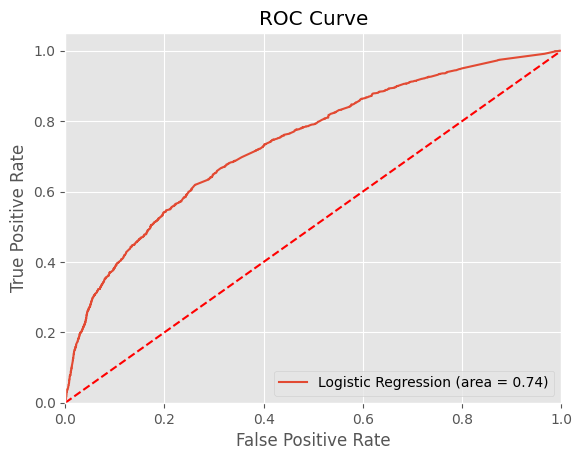

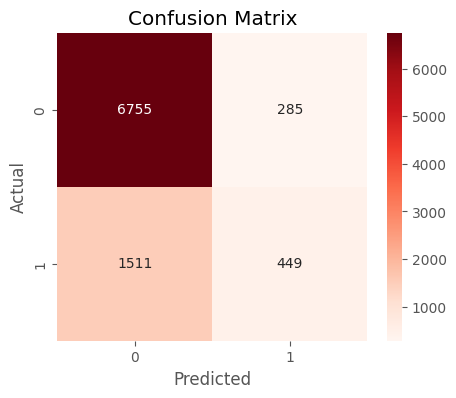

In [60]:
X = new_data[[ 'BILL_AMT1', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'LIMIT_BAL', 'PAY_AMT1', 'PAY_AMT3', 'EDUCATION', 'PAY_AMT2', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']]
y = new_data['default.payment.next.month']

# Séparation des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Instanciation du StandardScaler
scaler = StandardScaler()

# Mise à l'échelle des données d'entraînement
X_train_scaled = scaler.fit_transform(X_train)

# Mise à l'échelle des données de test en utilisant les paramètres de mise à l'échelle appris sur les données d'entraînement
X_test_scaled = scaler.transform(X_test)

# Initialisation du modèle de régression logistique
logit = LogisticRegression()

# Entraînement du modèle sur les données mises à l'échelle
logit.fit(X_train_scaled, y_train)

# Prédiction sur l'ensemble de test
pred_logit = logit.predict(X_test_scaled)

# Calcul de l'accuracy
accuracy = accuracy_score(y_test, pred_logit)
print("Logit model's accuracy:", accuracy)

# Affichage du rapport de classification
print(classification_report(y_test, pred_logit))

# Calcul de l'indice de Gini
y_pred_proba = logit.predict_proba(X_test_scaled)[:, 1]
gini_index = 2 * roc_auc_score(y_test, y_pred_proba) - 1
print("Gini Index:", gini_index)

# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, logit.predict_proba(X_test_scaled)[:, 1])

plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % roc_auc_score(y_test, y_pred_proba))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

# Matrice de confusion
conf_matrix = confusion_matrix(y_test, pred_logit)

# Affichage de la matrice de confusion sous forme de heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Logit model's accuracy: 0.8015555555555556
Gini Index: 0.4751503797541745
              precision    recall  f1-score   support

           0       0.82      0.96      0.88      7040
           1       0.62      0.23      0.34      1960

    accuracy                           0.80      9000
   macro avg       0.72      0.60      0.61      9000
weighted avg       0.77      0.80      0.76      9000

Gini Index: 0.4751503797541745


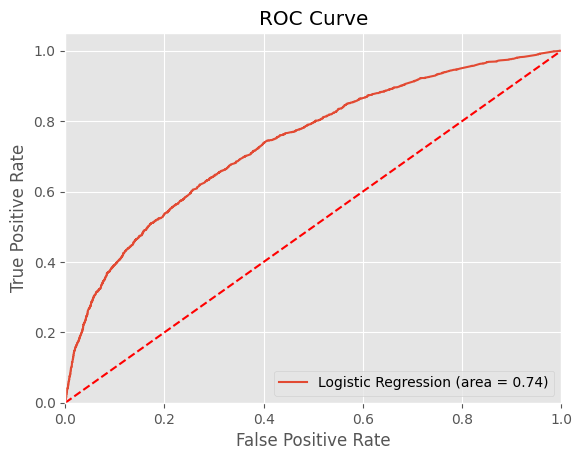

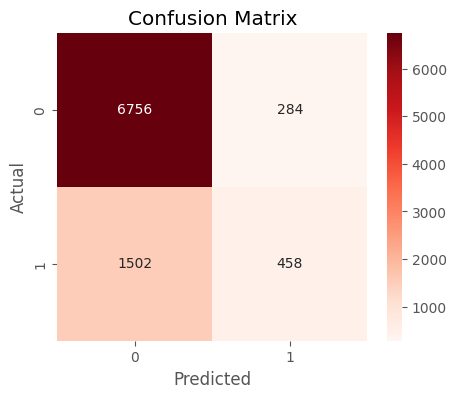

In [61]:
X = new_data[['MARRIAGE','SEX', 'BILL_AMT1', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'LIMIT_BAL', 'PAY_AMT1', 'PAY_AMT3', 'EDUCATION', 'PAY_AMT2', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']]
y = new_data['default.payment.next.month']

# Séparation des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Instanciation du StandardScaler
scaler = StandardScaler()

# Mise à l'échelle des données d'entraînement
X_train_scaled = scaler.fit_transform(X_train)

# Mise à l'échelle des données de test en utilisant les paramètres de mise à l'échelle appris sur les données d'entraînement
X_test_scaled = scaler.transform(X_test)

# Initialisation du modèle de régression logistique
logit = LogisticRegression()

# Entraînement du modèle sur les données mises à l'échelle
logit.fit(X_train_scaled, y_train)

# Prédiction sur l'ensemble de test
pred_logit = logit.predict(X_test_scaled)

# Calcul de l'accuracy
accuracy = accuracy_score(y_test, pred_logit)
print("Logit model's accuracy:", accuracy)
# Calcul de l'indice de Gini
y_pred_proba = logit.predict_proba(X_test_scaled)[:, 1]
gini_index = 2 * roc_auc_score(y_test, y_pred_proba) - 1
print("Gini Index:", gini_index)

# Affichage du rapport de classification
print(classification_report(y_test, pred_logit))

# Calcul de l'indice de Gini
y_pred_proba = logit.predict_proba(X_test_scaled)[:, 1]
gini_index = 2 * roc_auc_score(y_test, y_pred_proba) - 1
print("Gini Index:", gini_index)

# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, logit.predict_proba(X_test_scaled)[:, 1])

plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % roc_auc_score(y_test, y_pred_proba))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

# Matrice de confusion
conf_matrix = confusion_matrix(y_test, pred_logit)

# Affichage de la matrice de confusion sous forme de heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**3.  Random Forest**

Logit model's accuracy: 0.8015555555555556
Gini Index: 0.4751503797541745
              precision    recall  f1-score   support

           0       0.82      0.96      0.88      7040
           1       0.62      0.23      0.34      1960

    accuracy                           0.80      9000
   macro avg       0.72      0.60      0.61      9000
weighted avg       0.77      0.80      0.76      9000

Gini Index: 0.4751503797541745


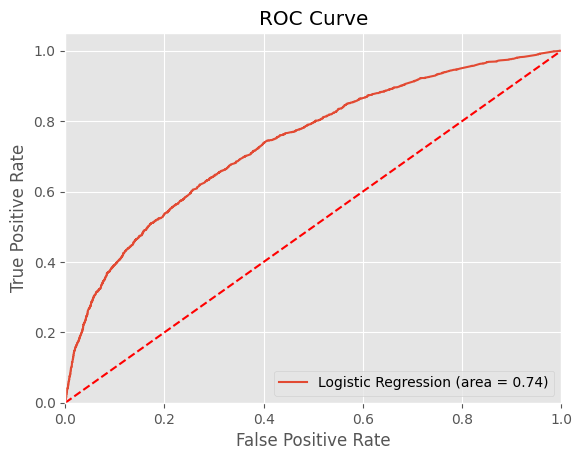

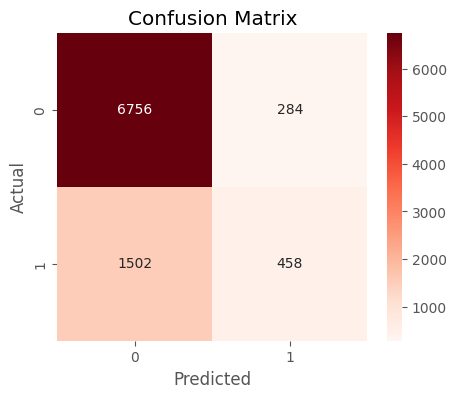

In [62]:
X = new_data[['MARRIAGE','SEX', 'BILL_AMT1', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'LIMIT_BAL', 'PAY_AMT1', 'PAY_AMT3', 'EDUCATION', 'PAY_AMT2', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']]
y = new_data['default.payment.next.month']

# Séparation des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Instanciation du StandardScaler
scaler = StandardScaler()

# Mise à l'échelle des données d'entraînement
X_train_scaled = scaler.fit_transform(X_train)

# Mise à l'échelle des données de test en utilisant les paramètres de mise à l'échelle appris sur les données d'entraînement
X_test_scaled = scaler.transform(X_test)

# Initialisation du modèle de régression logistique
logit = LogisticRegression()

# Entraînement du modèle sur les données mises à l'échelle
logit.fit(X_train_scaled, y_train)

# Prédiction sur l'ensemble de test
pred_logit = logit.predict(X_test_scaled)

# Calcul de l'accuracy
accuracy = accuracy_score(y_test, pred_logit)
print("Logit model's accuracy:", accuracy)
# Calcul de l'indice de Gini
y_pred_proba = logit.predict_proba(X_test_scaled)[:, 1]
gini_index = 2 * roc_auc_score(y_test, y_pred_proba) - 1
print("Gini Index:", gini_index)

# Affichage du rapport de classification
print(classification_report(y_test, pred_logit))

# Calcul de l'indice de Gini
y_pred_proba = logit.predict_proba(X_test_scaled)[:, 1]
gini_index = 2 * roc_auc_score(y_test, y_pred_proba) - 1
print("Gini Index:", gini_index)

# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, logit.predict_proba(X_test_scaled)[:, 1])

plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % roc_auc_score(y_test, y_pred_proba))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

# Matrice de confusion
conf_matrix = confusion_matrix(y_test, pred_logit)

# Affichage de la matrice de confusion sous forme de heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

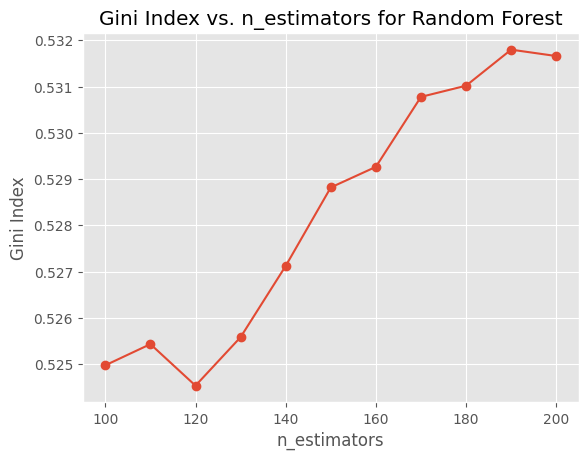

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
X = data.drop(['default.payment.next.month'], axis=1)
y = data['default.payment.next.month']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gini_index_values = []
n_estimators_values = []

n_estimators_range = [100,110,120,130,140,150,160,170,180,190,200]

for n_estimators in n_estimators_range:
    rf_classifier = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
    rf_classifier.fit(X_train, y_train)
   
    y_pred_proba = rf_classifier.predict_proba(X_test)[:, 1]
   
    auc_score = roc_auc_score(y_test, y_pred_proba)
   
    gini_index = 2 * auc_score - 1
   
    gini_index_values.append(gini_index)
    n_estimators_values.append(n_estimators)

plt.plot(n_estimators_values, gini_index_values, marker='o')
plt.xlabel('n_estimators')
plt.ylabel('Gini Index')
plt.title('Gini Index vs. n_estimators for Random Forest')
plt.grid(True)
plt.show()


